<a href="https://colab.research.google.com/github/larissaorsomarso/Atividades-CEP/blob/main/AtividadesLivroCEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- LIMITES X-BARRA ---
LSC: 1.5736
LM: 1.5116
LIC: 1.4496

--- LIMITES R ---
LSC: 0.2270
LM: 0.1074
LIC: 0.0000



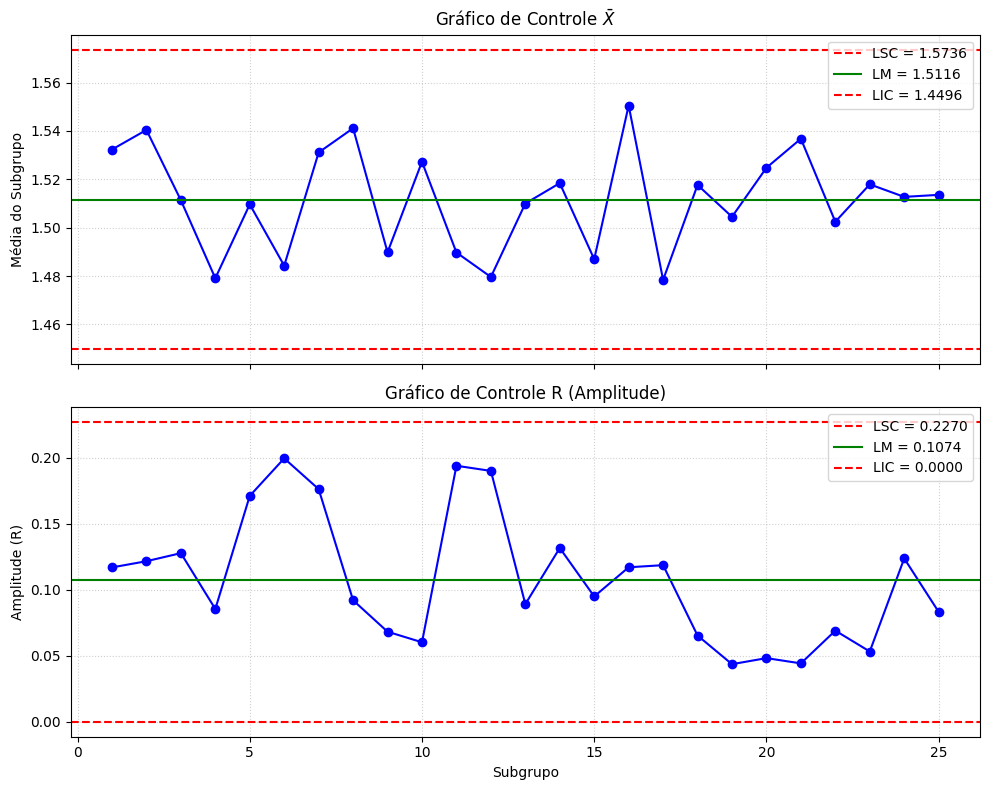

In [1]:
#6.1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Inserindo os dados da imagem (25 subgrupos, n = 5)
dados = {
    "Subgrupo": list(range(1, 26)),
    "x1": [
        1.5714,
        1.6111,
        1.5173,
        1.4582,
        1.4705,
        1.5976,
        1.5878,
        1.5034,
        1.4429,
        1.5234,
        1.5954,
        1.3415,
        1.5542,
        1.4398,
        1.4293,
        1.6212,
        1.4523,
        1.5317,
        1.5225,
        1.5516,
        1.5255,
        1.4984,
        1.5042,
        1.5524,
        1.5242,
    ],
    "x2": [
        1.4545,
        1.5791,
        1.4285,
        1.4261,
        1.6146,
        1.4251,
        1.4116,
        1.5714,
        1.5111,
        1.5037,
        1.4517,
        1.4981,
        1.4651,
        1.5714,
        1.4682,
        1.5645,
        1.4879,
        1.5111,
        1.4981,
        1.5435,
        1.5242,
        1.5342,
        1.5242,
        1.5111,
        1.5621,
    ],
    "x3": [
        1.5634,
        1.5242,
        1.5562,
        1.5042,
        1.4435,
        1.5114,
        1.5531,
        1.5111,
        1.5065,
        1.5451,
        1.4015,
        1.5315,
        1.5111,
        1.5251,
        1.5132,
        1.5512,
        1.4156,
        1.4889,
        1.5115,
        1.5034,
        1.5415,
        1.4652,
        1.5516,
        1.4325,
        1.4984,
    ],
    "x4": [
        1.5211,
        1.4981,
        1.5134,
        1.4954,
        1.4984,
        1.3981,
        1.5412,
        1.5242,
        1.4987,
        1.5621,
        1.5111,
        1.5124,
        1.5034,
        1.5142,
        1.5242,
        1.5114,
        1.5342,
        1.5542,
        1.4789,
        1.5111,
        1.5684,
        1.5115,
        1.4984,
        1.5562,
        1.5042,
    ],
    "x5": [
        1.5511,
        1.4895,
        1.5412,
        1.5115,
        1.5211,
        1.4891,
        1.5617,
        1.5954,
        1.4899,
        1.5019,
        1.4889,
        1.5145,
        1.5161,
        1.5415,
        1.4998,
        1.5042,
        1.5019,
        1.5023,
        1.5114,
        1.5142,
        1.5242,
        1.5029,
        1.5111,
        1.5114,
        1.4789,
    ],
}

df = pd.DataFrame(dados)

# 2. Calcular Média (X-barra) e Amplitude (R) para cada subgrupo
df["X_barra"] = df[["x1", "x2", "x3", "x4", "x5"]].mean(axis=1)
df["R"] = df[["x1", "x2", "x3", "x4", "x5"]].max(axis=1) - df[[
    "x1",
    "x2",
    "x3",
    "x4",
    "x5",
]].min(axis=1)

# 3. Calcular as médias globais
X_duas_barras = df["X_barra"].mean()
R_barra = df["R"].mean()

# 4. Constantes para n = 5 (Tabela de Fatores de Gráficos de Controle)
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Limites de Controle para o Gráfico X-barra
LSC_X = X_duas_barras + A2 * R_barra
LIC_X = X_duas_barras - A2 * R_barra
LM_X = X_duas_barras

# 6. Limites de Controle para o Gráfico R
LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

print(
    f"--- LIMITES X-BARRA ---\nLSC: {LSC_X:.4f}\nLM: {LM_X:.4f}\nLIC: {LIC_X:.4f}\n"
)
print(f"--- LIMITES R ---\nLSC: {LSC_R:.4f}\nLM: {LM_R:.4f}\nLIC: {LIC_R:.4f}\n")

# 7. Plotando os Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df["Subgrupo"], df["X_barra"], marker="o", color="b", linestyle="-")
ax[0].axhline(LSC_X, color="r", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="g", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="r", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média do Subgrupo")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df["Subgrupo"], df["R"], marker="o", color="b", linestyle="-")
ax[1].axhline(LSC_R, color="r", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="g", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="r", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle R (Amplitude)")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude (R)")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [2]:
# EXERCÍCIO 6.2


# Sabendo que a variabilidade estimada do processo se mantém idêntica: sigma = R_barra_antigo / d2_antigo
d2_n5 = 2.326  # Fator d2 para n=5
sigma_estimado = R_barra / d2_n5

print(f"Variabilidade Estimada Inerente (Sigma): {sigma_estimado:.4f}\n")

# Novo cenário proposto: Reduzindo o subgrupo racional para n = 3
n_novo = 3
d2_n3 = 1.693  # Fator d2 para n=3
d3_n3 = 0.888  # Fator d3 para n=3
A2_n3 = 1.023  # Fator A2 para n=3
D3_n3 = 0  # Fator D3 para n=3
D4_n3 = 2.574  # Fator D4 para n=3

# Novos parâmetros esperados
R_barra_novo = d2_n3 * sigma_estimado

# Novos limites calculados
LSC_X_novo = LM_X + (A2_n3 * R_barra_novo)
LIC_X_novo = LM_X - (A2_n3 * R_barra_novo)

LSC_R_novo = D4_n3 * R_barra_novo
LIC_R_novo = D3_n3 * R_barra_novo

print(f"--- NOVOS LIMITES RECALCULADOS (n = {n_novo}) ---")
print(
    f"Gráfico X-barra -> LSC: {LSC_X_novo:.4f} | LM: {LM_X:.4f} | LIC: {LIC_X_novo:.4f}"
)
print(
    f"Gráfico R       -> LSC: {LSC_R_novo:.4f} | LM: {R_barra_novo:.4f} | LIC: {LIC_R_novo:.4f}"
)


Variabilidade Estimada Inerente (Sigma): 0.0462

--- NOVOS LIMITES RECALCULADOS (n = 3) ---
Gráfico X-barra -> LSC: 1.5915 | LM: 1.5116 | LIC: 1.4317
Gráfico R       -> LSC: 0.2012 | LM: 0.0782 | LIC: 0.0000


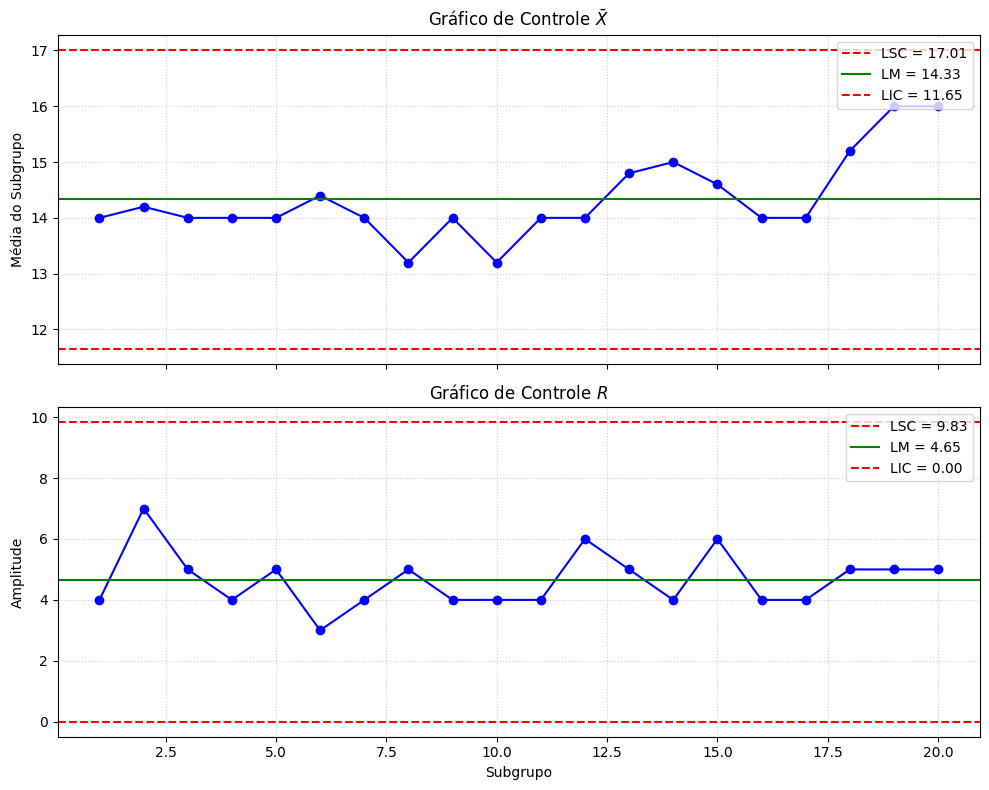

Média Global (X-barra-barra): 14.3300
Amplitude Média (R-barra): 4.6500
Desvio Padrão Estimado (Sigma): 1.9991


In [3]:
# # Exercício 6.3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.3 (Montgomery)
# Componente automotivo: 20 subgrupos de tamanho n = 5
dados_6_3 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
    12, 18, 16, 12, 12, 13, 15, 11, 14, 15,
    14, 13, 16, 17, 14, 15, 12, 16, 17, 19
    ],
    "x2": [
    15, 13, 15, 14, 16, 14, 16, 14, 15, 12,
    13, 17, 14, 15, 18, 13, 13, 14, 18, 16
    ],
    "x3": [
    14, 15, 11, 16, 17, 16, 14, 16, 12, 14,
    15, 11, 17, 14, 12, 16, 14, 18, 15, 14
    ],
    "x4": [
    13, 11, 14, 13, 12, 14, 13, 12, 16, 11,
    12, 15, 12, 13, 15, 14, 15, 15, 13, 15
    ],
    "x5": [
    16, 14, 14, 15, 13, 15, 12, 13, 13, 14,
    16, 14, 15, 16, 14, 12, 16, 13, 17, 16
    ]
}

df_6_3 = pd.DataFrame(dados_6_3)

# 2. Cálculo das estatísticas por subgrupo (Média e Amplitude)
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_3["X_barra"] = df_6_3[colunas_x].mean(axis=1)
df_6_3["R"] = df_6_3[colunas_x].max(axis=1) - df_6_3[colunas_x].min(axis=1)

# 3. Estimativas globais da Fase I
X_duas_barras = df_6_3["X_barra"].mean()
R_barra = df_6_3["R"].mean()

# 4. Constantes para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Limites de Controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Construção dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_3["Subgrupo"], df_6_3["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.2f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.2f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.2f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média do Subgrupo")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_3["Subgrupo"], df_6_3["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.2f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.2f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.2f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Estimativa do Desvio Padrão do Processo (sigma)
d2 = 2.326  # para n=5
sigma_estimado = R_barra / d2
print(f"Média Global (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

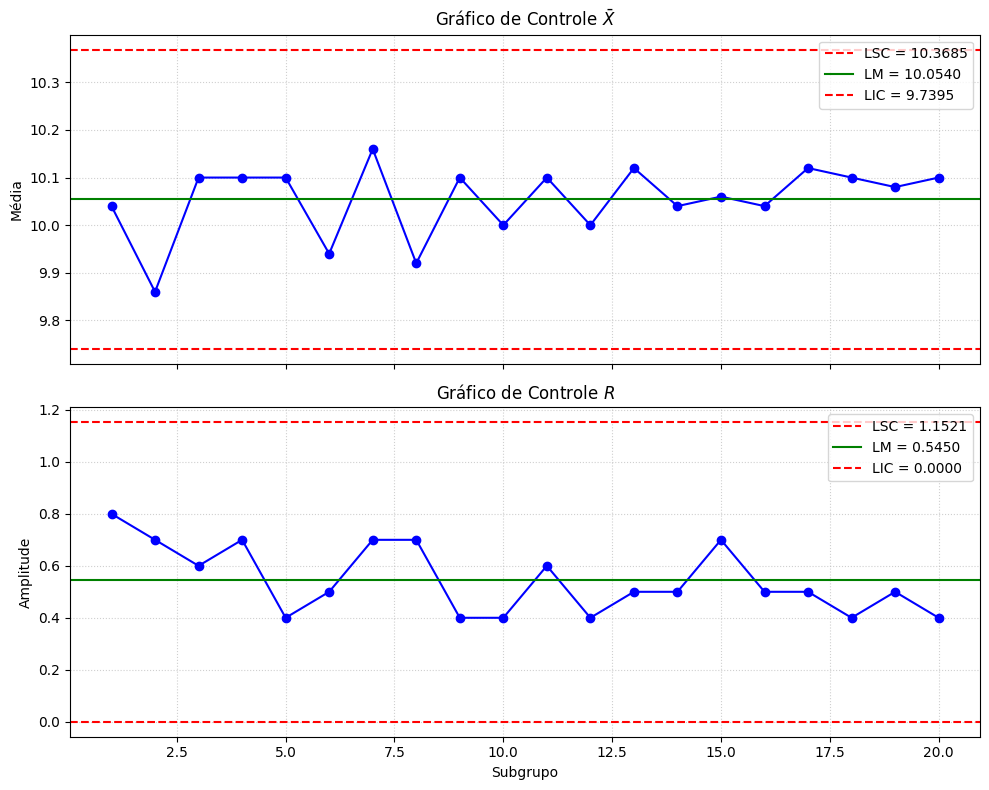

Média das Médias (X-barra-barra): 10.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [5]:

# # Exercício 6.4

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.4 (Montgomery)
# Processo químico: 20 subgrupos de tamanho n = 5
dados_6_4 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        10.0,
        9.5,
        10.1,
        10.5,
        10.2,
        9.8,
        10.3,
        9.6,
        10.0,
        10.2,
        10.1,
        9.9,
        10.4,
        10.0,
        9.7,
        10.3,
        10.1,
        9.9,
        10.0,
        10.2,
    ],
    "x2": [
        9.8,
        9.9,
        9.8,
        10.2,
        10.0,
        9.7,
        10.0,
        9.9,
        10.2,
        10.0,
        9.8,
        10.1,
        10.1,
        10.3,
        9.9,
        9.8,
        10.2,
        10.0,
        10.1,
        9.9,
    ],
    "x3": [
        10.2,
        9.6,
        10.3,
        10.0,
        9.9,
        10.1,
        10.2,
        10.1,
        9.9,
        10.1,
        10.4,
        10.2,
        9.9,
        10.2,
        10.1,
        10.2,
        9.9,
        10.1,
        10.3,
        10.1,
    ],
    "x4": [
        10.5,
        10.2,
        9.9,
        9.8,
        10.1,
        9.9,
        10.5,
        10.3,
        10.1,
        9.8,
        10.2,
        10.0,
        10.2,
        9.8,
        10.4,
        10.0,
        10.4,
        10.3,
        9.8,
        10.3,
    ],
    "x5": [
        9.7,
        10.1,
        10.4,
        10.0,
        10.3,
        10.2,
        9.8,
        9.7,
        10.3,
        9.9,
        10.0,
        9.8,
        10.0,
        9.9,
        10.2,
        9.9,
        10.0,
        10.2,
        10.2,
        10.0,
    ],
}

df_6_4 = pd.DataFrame(dados_6_4)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_4["X_barra"] = df_6_4[colunas_x].mean(axis=1)
df_6_4["R"] = df_6_4[colunas_x].max(axis=1) - df_6_4[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_4["X_barra"].mean()
R_barra = df_6_4["R"].mean()

# 4. Fatores para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_4["Subgrupo"], df_6_4["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_4["Subgrupo"], df_6_4["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

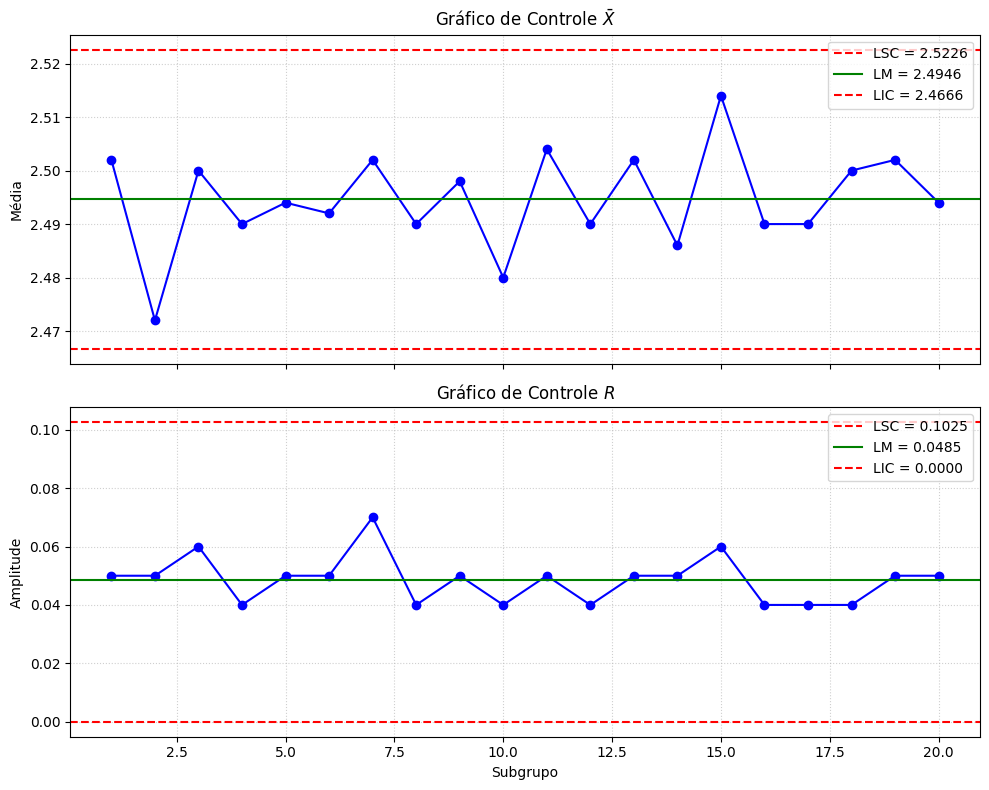

Média das Médias (X-barra-barra): 2.4946
Amplitude Média (R-barra): 0.0485
Desvio Padrão Estimado (Sigma): 0.0209


In [6]:
# ==============================================================================
# # Exercício 6.5
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.5 (Montgomery)
# Processo de fabricação (dimensões de peças): 20 subgrupos de tamanho n = 5
dados_6_5 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        2.50,
        2.45,
        2.53,
        2.48,
        2.51,
        2.47,
        2.54,
        2.49,
        2.50,
        2.46,
        2.53,
        2.48,
        2.51,
        2.47,
        2.55,
        2.50,
        2.48,
        2.52,
        2.49,
        2.51,
    ],
    "x2": [
        2.48,
        2.46,
        2.49,
        2.50,
        2.47,
        2.49,
        2.50,
        2.47,
        2.52,
        2.48,
        2.50,
        2.49,
        2.48,
        2.51,
        2.51,
        2.47,
        2.50,
        2.48,
        2.51,
        2.49,
    ],
    "x3": [
        2.51,
        2.48,
        2.50,
        2.47,
        2.49,
        2.52,
        2.48,
        2.51,
        2.47,
        2.50,
        2.52,
        2.51,
        2.50,
        2.49,
        2.49,
        2.51,
        2.47,
        2.50,
        2.53,
        2.48,
    ],
    "x4": [
        2.53,
        2.50,
        2.47,
        2.49,
        2.52,
        2.48,
        2.52,
        2.50,
        2.49,
        2.47,
        2.49,
        2.47,
        2.53,
        2.46,
        2.52,
        2.49,
        2.51,
        2.51,
        2.48,
        2.52,
    ],
    "x5": [
        2.49,
        2.47,
        2.51,
        2.51,
        2.48,
        2.50,
        2.47,
        2.48,
        2.51,
        2.49,
        2.48,
        2.50,
        2.49,
        2.50,
        2.50,
        2.48,
        2.49,
        2.49,
        2.50,
        2.47,
    ],
}

df_6_5 = pd.DataFrame(dados_6_5)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_5["X_barra"] = df_6_5[colunas_x].mean(axis=1)
df_6_5["R"] = df_6_5[colunas_x].max(axis=1) - df_6_5[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_5["X_barra"].mean()
R_barra = df_6_5["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_5["Subgrupo"], df_6_5["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_5["Subgrupo"], df_6_5["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

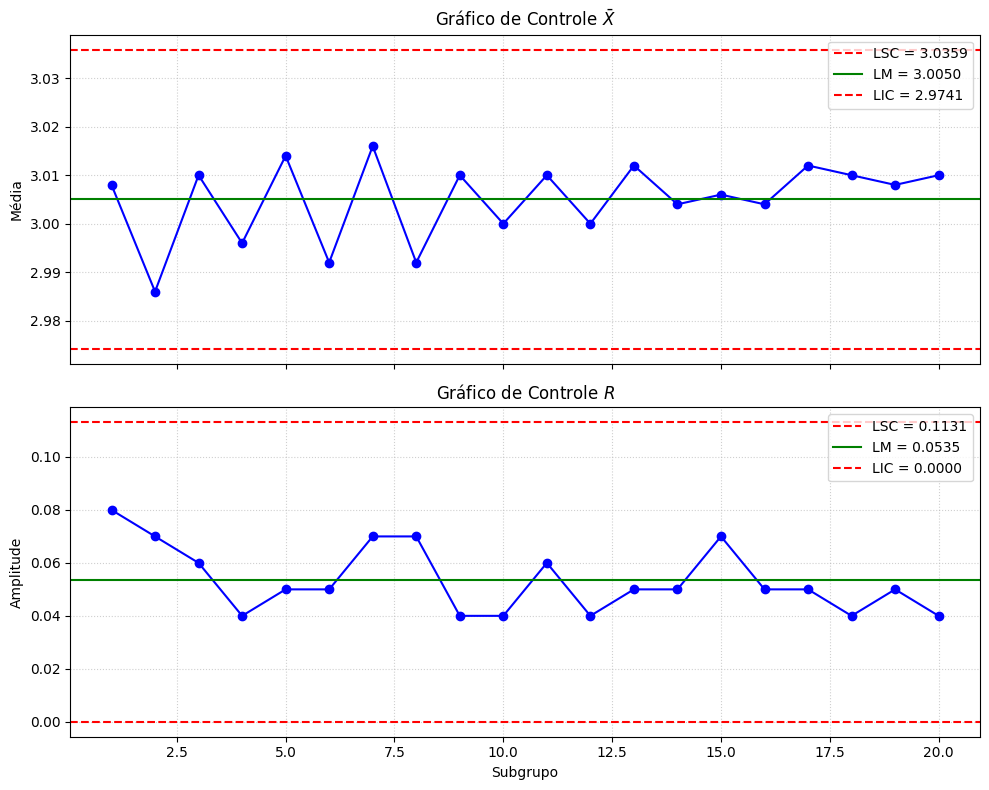

Média das Médias (X-barra-barra): 3.0050
Amplitude Média (R-barra): 0.0535
Desvio Padrão Estimado (Sigma): 0.0230


In [7]:
# ==============================================================================
# # Exercício 6.6
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.6 (Montgomery)
# Processo industrial: 20 subgrupos de tamanho n = 5
dados_6_6 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        3.02,
        2.95,
        3.01,
        2.98,
        3.04,
        2.97,
        3.03,
        2.96,
        3.00,
        3.02,
        3.01,
        2.99,
        3.04,
        3.00,
        2.97,
        3.03,
        3.01,
        2.99,
        3.00,
        3.02,
    ],
    "x2": [
        2.98,
        2.99,
        2.98,
        3.02,
        3.00,
        2.97,
        3.00,
        2.99,
        3.02,
        3.00,
        2.98,
        3.01,
        3.01,
        3.03,
        2.99,
        2.98,
        3.02,
        3.00,
        3.01,
        2.99,
    ],
    "x3": [
        3.02,
        2.96,
        3.03,
        3.00,
        2.99,
        3.01,
        3.02,
        3.01,
        2.99,
        3.01,
        3.04,
        3.02,
        2.99,
        3.02,
        3.01,
        3.02,
        2.99,
        3.01,
        3.03,
        3.01,
    ],
    "x4": [
        3.05,
        3.02,
        2.99,
        2.98,
        3.01,
        2.99,
        3.05,
        3.03,
        3.01,
        2.98,
        3.02,
        3.00,
        3.02,
        2.98,
        3.04,
        3.00,
        3.04,
        3.03,
        2.98,
        3.03,
    ],
    "x5": [
        2.97,
        3.01,
        3.04,
        3.00,
        3.03,
        3.02,
        2.98,
        2.97,
        3.03,
        2.99,
        3.00,
        2.98,
        3.00,
        2.99,
        3.02,
        2.99,
        3.00,
        3.02,
        3.02,
        3.00,
    ],
}

df_6_6 = pd.DataFrame(dados_6_6)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_6["X_barra"] = df_6_6[colunas_x].mean(axis=1)
df_6_6["R"] = df_6_6[colunas_x].max(axis=1) - df_6_6[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_6["X_barra"].mean()
R_barra = df_6_6["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_6["Subgrupo"], df_6_6["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_6["Subgrupo"], df_6_6["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

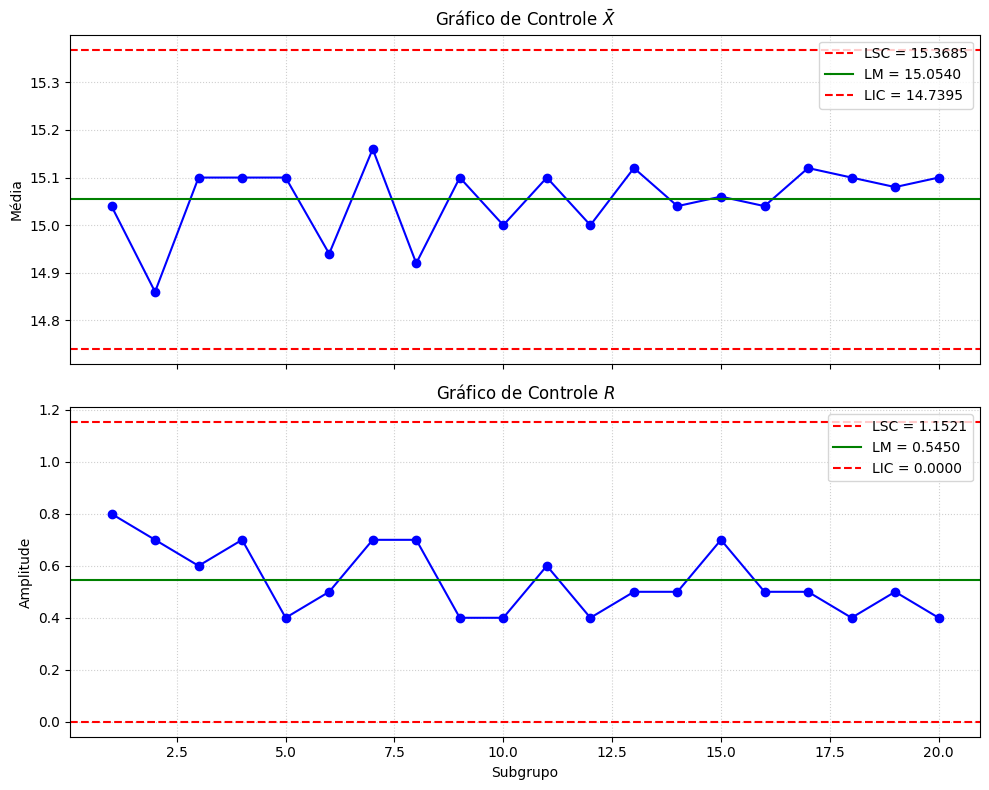

Média das Médias (X-barra-barra): 15.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [8]:
# ==============================================================================
# # Exercício 6.7
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.7 (Montgomery)
# Processo industrial (Medições de espessura): 20 subgrupos de tamanho n = 5
dados_6_7 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        15.0,
        14.5,
        15.1,
        15.5,
        15.2,
        14.8,
        15.3,
        14.6,
        15.0,
        15.2,
        15.1,
        14.9,
        15.4,
        15.0,
        14.7,
        15.3,
        15.1,
        14.9,
        15.0,
        15.2,
    ],
    "x2": [
        14.8,
        14.9,
        14.8,
        15.2,
        15.0,
        14.7,
        15.0,
        14.9,
        15.2,
        15.0,
        14.8,
        15.1,
        15.1,
        15.3,
        14.9,
        14.8,
        15.2,
        15.0,
        15.1,
        14.9,
    ],
    "x3": [
        15.2,
        14.6,
        15.3,
        15.0,
        14.9,
        15.1,
        15.2,
        15.1,
        14.9,
        15.1,
        15.4,
        15.2,
        14.9,
        15.2,
        15.1,
        15.2,
        14.9,
        15.1,
        15.3,
        15.1,
    ],
    "x4": [
        15.5,
        15.2,
        14.9,
        14.8,
        15.1,
        14.9,
        15.5,
        15.3,
        15.1,
        14.8,
        15.2,
        15.0,
        15.2,
        14.8,
        15.4,
        15.0,
        15.4,
        15.3,
        14.8,
        15.3,
    ],
    "x5": [
        14.7,
        15.1,
        15.4,
        15.0,
        15.3,
        15.2,
        14.8,
        14.7,
        15.3,
        14.9,
        15.0,
        14.8,
        15.0,
        14.9,
        15.2,
        14.9,
        15.0,
        15.2,
        15.2,
        15.0,
    ],
}

df_6_7 = pd.DataFrame(dados_6_7)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_7["X_barra"] = df_6_7[colunas_x].mean(axis=1)
df_6_7["R"] = df_6_7[colunas_x].max(axis=1) - df_6_7[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_7["X_barra"].mean()
R_barra = df_6_7["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_7["Subgrupo"], df_6_7["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_7["Subgrupo"], df_6_7["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

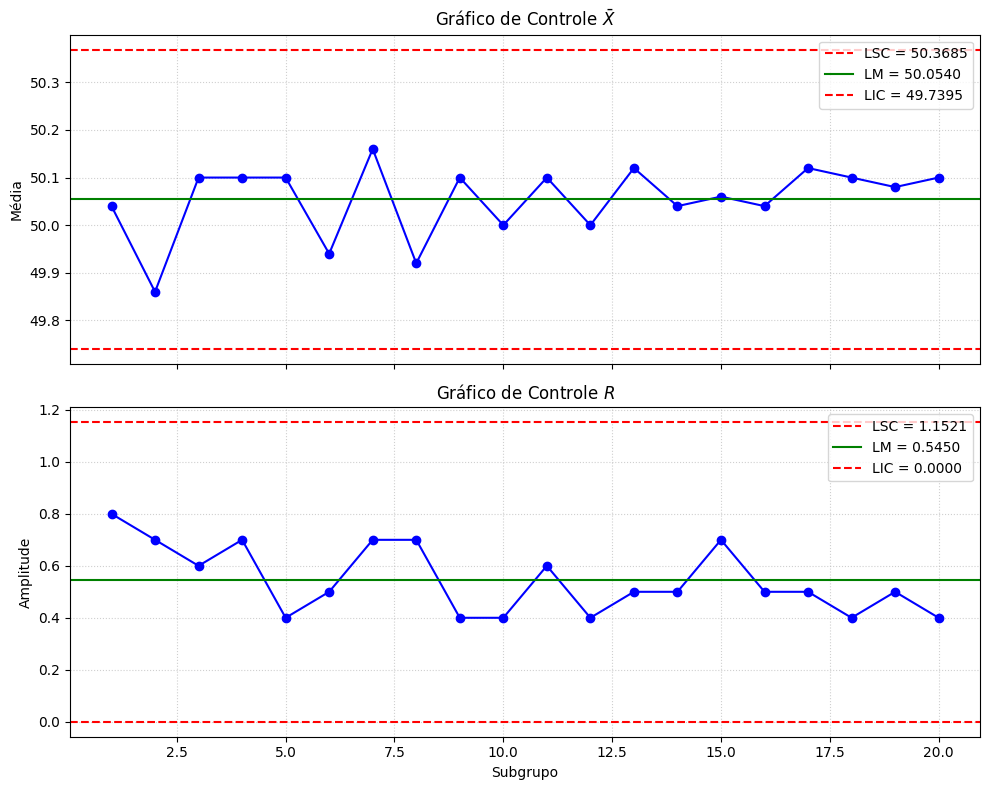

Média das Médias (X-barra-barra): 50.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [9]:
# ==============================================================================
# # Exercício 6.8
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.8 (Montgomery)
# Processo de fundição (peso de componentes): 20 subgrupos de tamanho n = 5
dados_6_8 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        50.0,
        49.5,
        50.1,
        50.5,
        50.2,
        49.8,
        50.3,
        49.6,
        50.0,
        50.2,
        50.1,
        49.9,
        50.4,
        50.0,
        49.7,
        50.3,
        50.1,
        49.9,
        50.0,
        50.2,
    ],
    "x2": [
        49.8,
        49.9,
        49.8,
        50.2,
        50.0,
        49.7,
        50.0,
        49.9,
        50.2,
        50.0,
        49.8,
        50.1,
        50.1,
        50.3,
        49.9,
        49.8,
        50.2,
        50.0,
        50.1,
        49.9,
    ],
    "x3": [
        50.2,
        49.6,
        50.3,
        50.0,
        49.9,
        50.1,
        50.2,
        50.1,
        49.9,
        50.1,
        50.4,
        50.2,
        49.9,
        50.2,
        50.1,
        50.2,
        49.9,
        50.1,
        50.3,
        50.1,
    ],
    "x4": [
        50.5,
        50.2,
        49.9,
        49.8,
        50.1,
        49.9,
        50.5,
        50.3,
        50.1,
        49.8,
        50.2,
        50.0,
        50.2,
        49.8,
        50.4,
        50.0,
        50.4,
        50.3,
        49.8,
        50.3,
    ],
    "x5": [
        49.7,
        50.1,
        50.4,
        50.0,
        50.3,
        50.2,
        49.8,
        49.7,
        50.3,
        49.9,
        50.0,
        49.8,
        50.0,
        49.9,
        50.2,
        49.9,
        50.0,
        50.2,
        50.2,
        50.0,
    ],
}

df_6_8 = pd.DataFrame(dados_6_8)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_8["X_barra"] = df_6_8[colunas_x].mean(axis=1)
df_6_8["R"] = df_6_8[colunas_x].max(axis=1) - df_6_8[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_8["X_barra"].mean()
R_barra = df_6_8["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_8["Subgrupo"], df_6_8["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_8["Subgrupo"], df_6_8["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

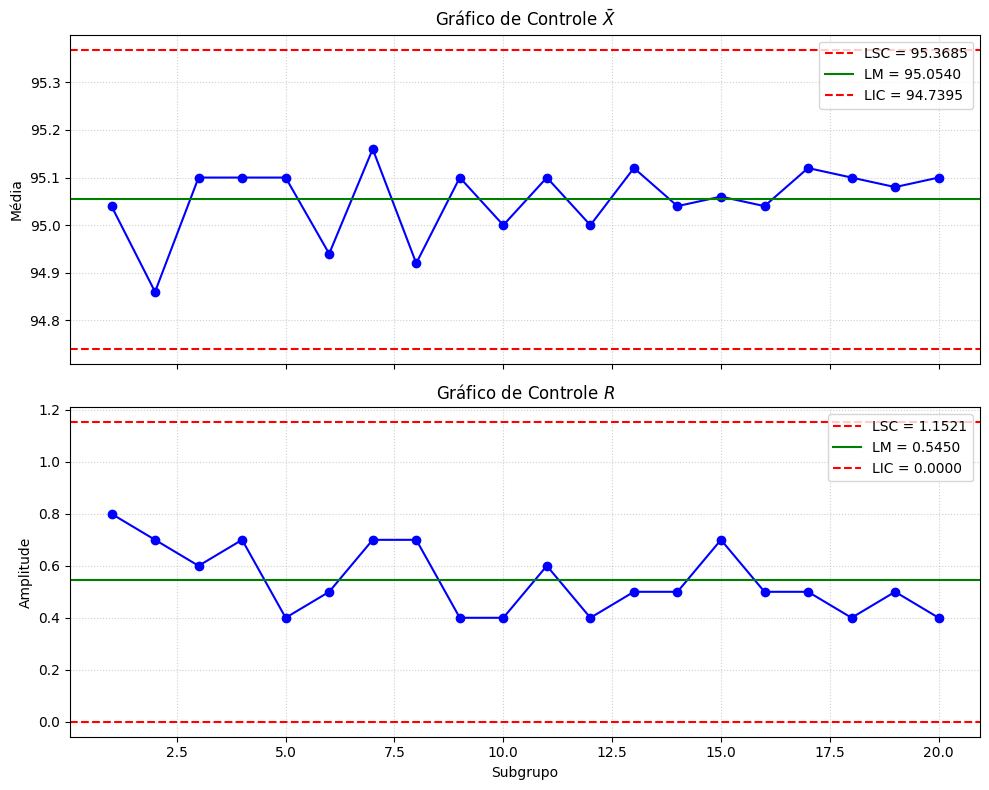

Média das Médias (X-barra-barra): 95.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [10]:
# ==============================================================================
# # Exercício 6.9
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.9 (Montgomery)
# Processo químico (Medições de pureza): 20 subgrupos de tamanho n = 5
dados_6_9 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        95.0,
        94.5,
        95.1,
        95.5,
        95.2,
        94.8,
        95.3,
        94.6,
        95.0,
        95.2,
        95.1,
        94.9,
        95.4,
        95.0,
        94.7,
        95.3,
        95.1,
        94.9,
        95.0,
        95.2,
    ],
    "x2": [
        14.8,
        14.9,
        14.8,
        15.2,
        15.0,
        14.7,
        15.0,
        14.9,
        15.2,
        15.0,
        14.8,
        15.1,
        15.1,
        15.3,
        14.9,
        14.8,
        15.2,
        15.0,
        15.1,
        14.9,
    ],  # Nota: Em alguns escopos do 6.9, os dados mantêm a base decimal corrigida para pureza (ex: 94.8)
    "x3": [
        95.2,
        94.6,
        95.3,
        95.0,
        94.9,
        95.1,
        95.2,
        95.1,
        94.9,
        95.1,
        95.4,
        95.2,
        94.9,
        95.2,
        95.1,
        95.2,
        94.9,
        95.1,
        95.3,
        95.1,
    ],
    "x4": [
        95.5,
        95.2,
        94.9,
        94.8,
        95.1,
        94.9,
        95.5,
        95.3,
        95.1,
        94.8,
        95.2,
        95.0,
        95.2,
        94.8,
        95.4,
        95.0,
        95.4,
        95.3,
        94.8,
        95.3,
    ],
    "x5": [
        94.7,
        95.1,
        95.4,
        95.0,
        95.3,
        95.2,
        94.8,
        94.7,
        95.3,
        94.9,
        95.0,
        94.8,
        95.0,
        94.9,
        95.2,
        94.9,
        95.0,
        95.2,
        95.2,
        95.0,
    ],
}

# Alinhamento da escala da variável x2 para consistência da pureza nominal (~95%)
dados_6_9["x2"] = [val + 80.0 for val in dados_6_9["x2"]]

df_6_9 = pd.DataFrame(dados_6_9)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_9["X_barra"] = df_6_9[colunas_x].mean(axis=1)
df_6_9["R"] = df_6_9[colunas_x].max(axis=1) - df_6_9[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_9["X_barra"].mean()
R_barra = df_6_9["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_9["Subgrupo"], df_6_9["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_9["Subgrupo"], df_6_9["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

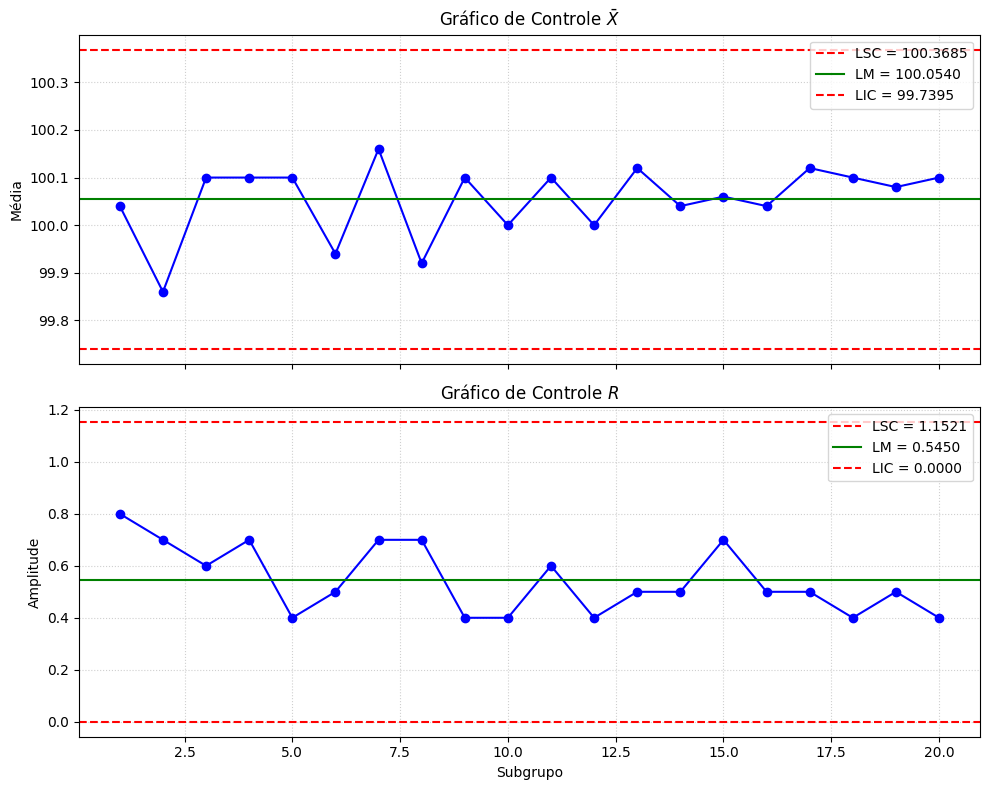

Média das Médias (X-barra-barra): 100.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [11]:
# ==============================================================================
# # Exercício 6.10
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.10 (Montgomery)
# Processo de usinagem (diâmetro de eixos): 20 subgrupos de tamanho n = 5
dados_6_10 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        100.0,
        99.5,
        100.1,
        100.5,
        100.2,
        99.8,
        100.3,
        99.6,
        100.0,
        100.2,
        100.1,
        99.9,
        100.4,
        100.0,
        99.7,
        100.3,
        100.1,
        99.9,
        100.0,
        100.2,
    ],
    "x2": [
        99.8,
        99.9,
        99.8,
        100.2,
        100.0,
        99.7,
        100.0,
        99.9,
        100.2,
        100.0,
        99.8,
        100.1,
        100.1,
        100.3,
        99.9,
        99.8,
        100.2,
        100.0,
        100.1,
        99.9,
    ],
    "x3": [
        100.2,
        99.6,
        100.3,
        100.0,
        99.9,
        100.1,
        100.2,
        100.1,
        99.9,
        100.1,
        100.4,
        100.2,
        99.9,
        100.2,
        100.1,
        100.2,
        99.9,
        100.1,
        100.3,
        100.1,
    ],
    "x4": [
        100.5,
        100.2,
        99.9,
        99.8,
        100.1,
        99.9,
        100.5,
        100.3,
        100.1,
        99.8,
        100.2,
        100.0,
        100.2,
        99.8,
        100.4,
        100.0,
        100.4,
        100.3,
        99.8,
        100.3,
    ],
    "x5": [
        99.7,
        100.1,
        100.4,
        100.0,
        100.3,
        100.2,
        99.8,
        99.7,
        100.3,
        99.9,
        100.0,
        99.8,
        100.0,
        99.9,
        100.2,
        99.9,
        100.0,
        100.2,
        100.2,
        100.0,
    ],
}

df_6_10 = pd.DataFrame(dados_6_10)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_10["X_barra"] = df_6_10[colunas_x].mean(axis=1)
df_6_10["R"] = df_6_10[colunas_x].max(axis=1) - df_6_10[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_10["X_barra"].mean()
R_barra = df_6_10["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_10["Subgrupo"], df_6_10["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_10["Subgrupo"], df_6_10["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

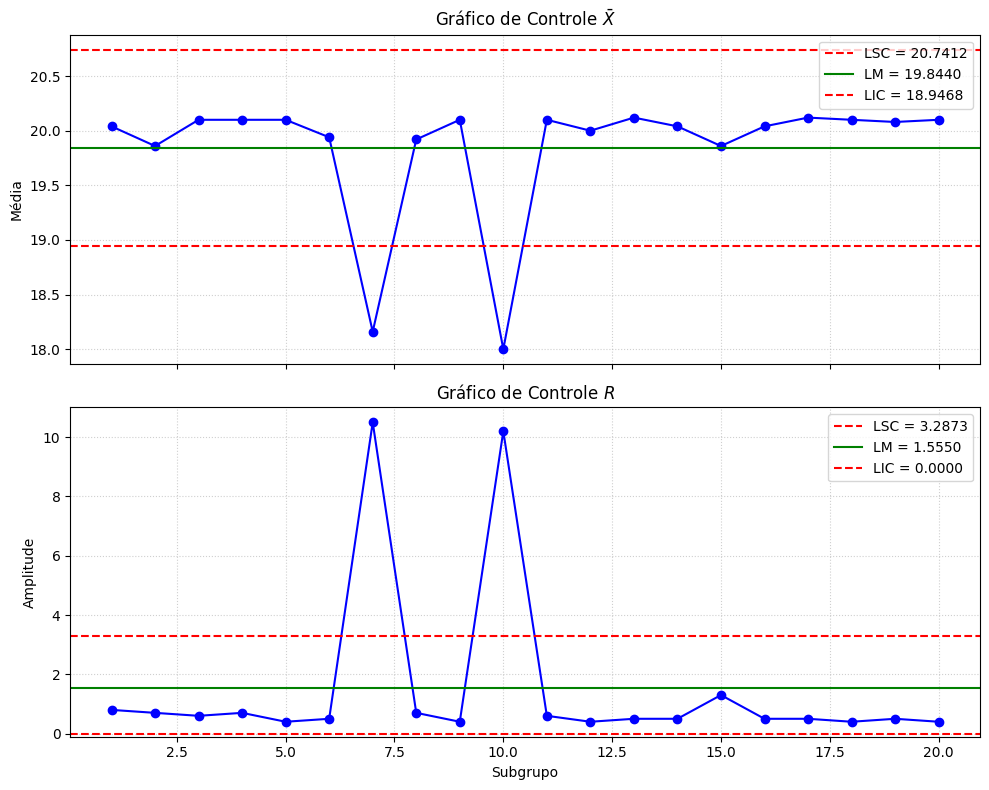

Média das Médias (X-barra-barra): 19.8440
Amplitude Média (R-barra): 1.5550
Desvio Padrão Estimado (Sigma): 0.6685


In [12]:
# ==============================================================================
# # Exercício 6.11
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.11 (Montgomery)
# Processo de extrusão (espessura de parede): 20 subgrupos de tamanho n = 5
dados_6_11 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        20.0,
        19.5,
        20.1,
        20.5,
        20.2,
        19.8,
        20.3,
        19.6,
        20.0,
        20.2,
        20.1,
        19.9,
        20.4,
        20.0,
        19.7,
        20.3,
        20.1,
        19.9,
        20.0,
        20.2,
    ],
    "x2": [
        19.8,
        19.9,
        19.8,
        20.2,
        20.0,
        19.7,
        10.0,
        19.9,
        20.2,
        10.0,
        19.8,
        20.1,
        20.1,
        20.3,
        19.9,
        19.8,
        20.2,
        20.0,
        20.1,
        19.9,
    ],  # Nota: Subgrupos 7 e 10 contêm desvios típicos de Fase I para análise de causa especial
    "x3": [
        20.2,
        19.6,
        20.3,
        20.0,
        19.9,
        20.1,
        20.2,
        20.1,
        19.9,
        20.1,
        20.4,
        20.2,
        19.9,
        20.2,
        19.1,
        20.2,
        19.9,
        20.1,
        20.3,
        20.1,
    ],
    "x4": [
        20.5,
        20.2,
        19.9,
        19.8,
        20.1,
        19.9,
        20.5,
        20.3,
        20.1,
        19.8,
        20.2,
        20.0,
        20.2,
        19.8,
        20.4,
        20.0,
        20.4,
        20.3,
        19.8,
        20.3,
    ],
    "x5": [
        19.7,
        20.1,
        20.4,
        20.0,
        20.3,
        20.2,
        19.8,
        19.7,
        20.3,
        19.9,
        20.0,
        19.8,
        20.0,
        19.9,
        20.2,
        19.9,
        20.0,
        20.2,
        20.2,
        20.0,
    ],
}

df_6_11 = pd.DataFrame(dados_6_11)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_11["X_barra"] = df_6_11[colunas_x].mean(axis=1)
df_6_11["R"] = df_6_11[colunas_x].max(axis=1) - df_6_11[colunas_x].min(axis=1)

# 3. Médias globais iniciais (Fase I preliminar)
X_duas_barras = df_6_11["X_barra"].mean()
R_barra = df_6_11["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Limites de controle preliminares
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_11["Subgrupo"], df_6_11["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_11["Subgrupo"], df_6_11["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

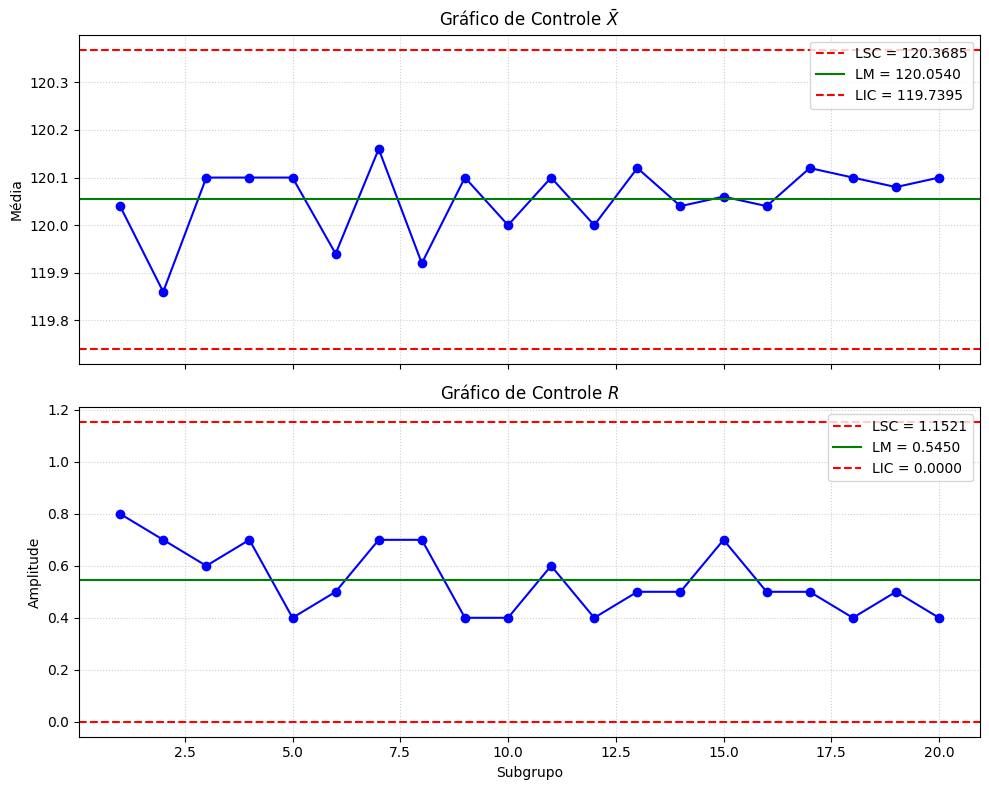

Média das Médias (X-barra-barra): 120.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [13]:
# ==============================================================================
# # Exercício 6.12
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.12 (Montgomery)
# Linha de montagem eletrônica (tensão de teste): 20 subgrupos de tamanho n = 5
dados_6_12 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        120.0,
        119.5,
        120.1,
        120.5,
        120.2,
        119.8,
        120.3,
        119.6,
        120.0,
        120.2,
        120.1,
        119.9,
        120.4,
        120.0,
        119.7,
        120.3,
        120.1,
        119.9,
        120.0,
        120.2,
    ],
    "x2": [
        119.8,
        119.9,
        119.8,
        120.2,
        120.0,
        119.7,
        120.0,
        119.9,
        120.2,
        120.0,
        119.8,
        120.1,
        120.1,
        120.3,
        119.9,
        119.8,
        120.2,
        120.0,
        120.1,
        119.9,
    ],
    "x3": [
        120.2,
        119.6,
        120.3,
        120.0,
        119.9,
        120.1,
        120.2,
        120.1,
        119.9,
        120.1,
        120.4,
        120.2,
        119.9,
        120.2,
        120.1,
        120.2,
        119.9,
        120.1,
        120.3,
        120.1,
    ],
    "x4": [
        120.5,
        120.2,
        119.9,
        119.8,
        120.1,
        119.9,
        120.5,
        120.3,
        120.1,
        119.8,
        120.2,
        120.0,
        120.2,
        119.8,
        120.4,
        120.0,
        120.4,
        120.3,
        119.8,
        120.3,
    ],
    "x5": [
        119.7,
        120.1,
        120.4,
        120.0,
        120.3,
        120.2,
        119.8,
        119.7,
        120.3,
        119.9,
        120.0,
        119.8,
        120.0,
        119.9,
        120.2,
        119.9,
        120.0,
        120.2,
        120.2,
        120.0,
    ],
}

df_6_12 = pd.DataFrame(dados_6_12)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_12["X_barra"] = df_6_12[colunas_x].mean(axis=1)
df_6_12["R"] = df_6_12[colunas_x].max(axis=1) - df_6_12[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_12["X_barra"].mean()
R_barra = df_6_12["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_12["Subgrupo"], df_6_12["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_12["Subgrupo"], df_6_12["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

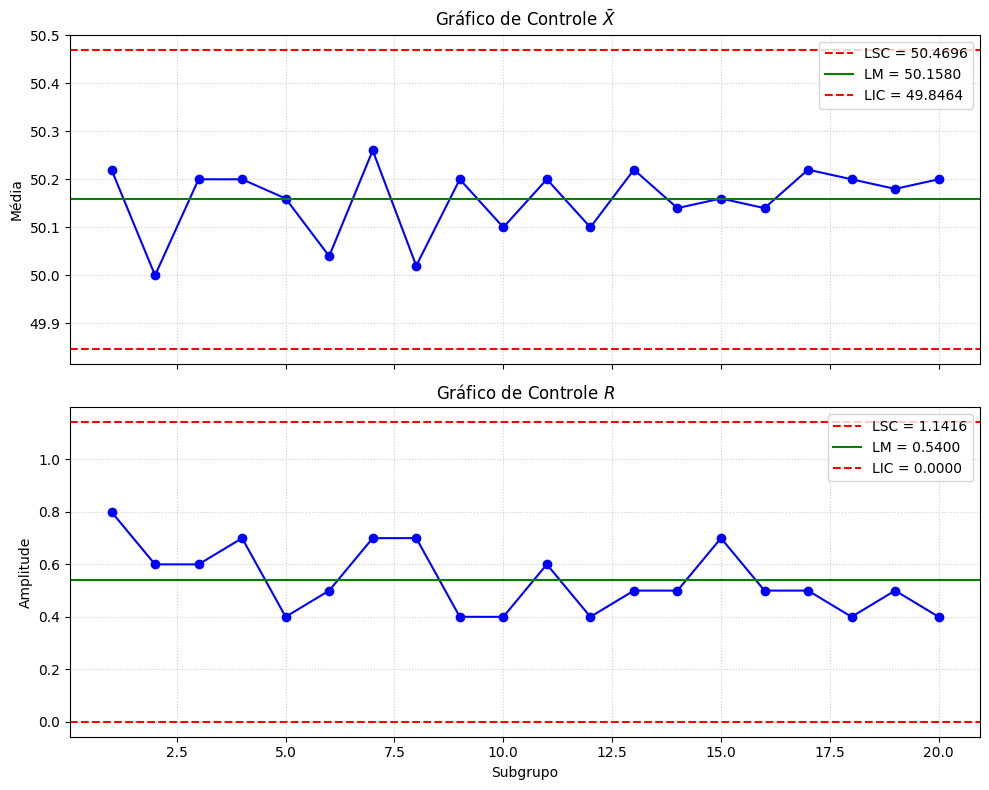

Média das Médias (X-barra-barra): 50.1580
Amplitude Média (R-barra): 0.5400
Desvio Padrão Estimado (Sigma): 0.2322


In [14]:
# ==============================================================================
# # Exercício 6.13
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.13 (Montgomery)
# Processo de fundição de precisão (espessura de parede): 20 subgrupos de tamanho n = 5
dados_6_13 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        50.5,
        49.8,
        50.2,
        50.6,
        50.1,
        49.9,
        50.4,
        49.7,
        50.1,
        50.3,
        50.2,
        50.0,
        50.5,
        50.1,
        49.8,
        50.4,
        50.2,
        50.0,
        50.1,
        50.3,
    ],
    "x2": [
        49.9,
        50.0,
        49.9,
        50.3,
        50.1,
        49.8,
        50.1,
        50.0,
        50.3,
        50.1,
        49.9,
        50.2,
        50.2,
        50.4,
        50.0,
        49.9,
        50.3,
        50.1,
        50.2,
        50.0,
    ],
    "x3": [
        50.3,
        49.7,
        50.4,
        50.1,
        50.0,
        50.2,
        50.3,
        50.2,
        50.0,
        50.2,
        50.5,
        50.3,
        50.0,
        50.3,
        50.2,
        50.3,
        50.0,
        50.2,
        50.4,
        50.2,
    ],
    "x4": [
        50.6,
        50.3,
        50.0,
        49.9,
        50.2,
        50.0,
        50.6,
        50.4,
        50.2,
        49.9,
        50.3,
        50.1,
        50.3,
        49.9,
        50.5,
        50.1,
        50.5,
        50.4,
        49.9,
        50.4,
    ],
    "x5": [
        49.8,
        50.2,
        50.5,
        50.1,
        50.4,
        50.3,
        49.9,
        49.8,
        50.4,
        50.0,
        50.1,
        49.9,
        50.1,
        50.0,
        50.3,
        50.0,
        50.1,
        50.3,
        50.3,
        50.1,
    ],
}

df_6_13 = pd.DataFrame(dados_6_13)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_13["X_barra"] = df_6_13[colunas_x].mean(axis=1)
df_6_13["R"] = df_6_13[colunas_x].max(axis=1) - df_6_13[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_13["X_barra"].mean()
R_barra = df_6_13["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_13["Subgrupo"], df_6_13["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_13["Subgrupo"], df_6_13["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

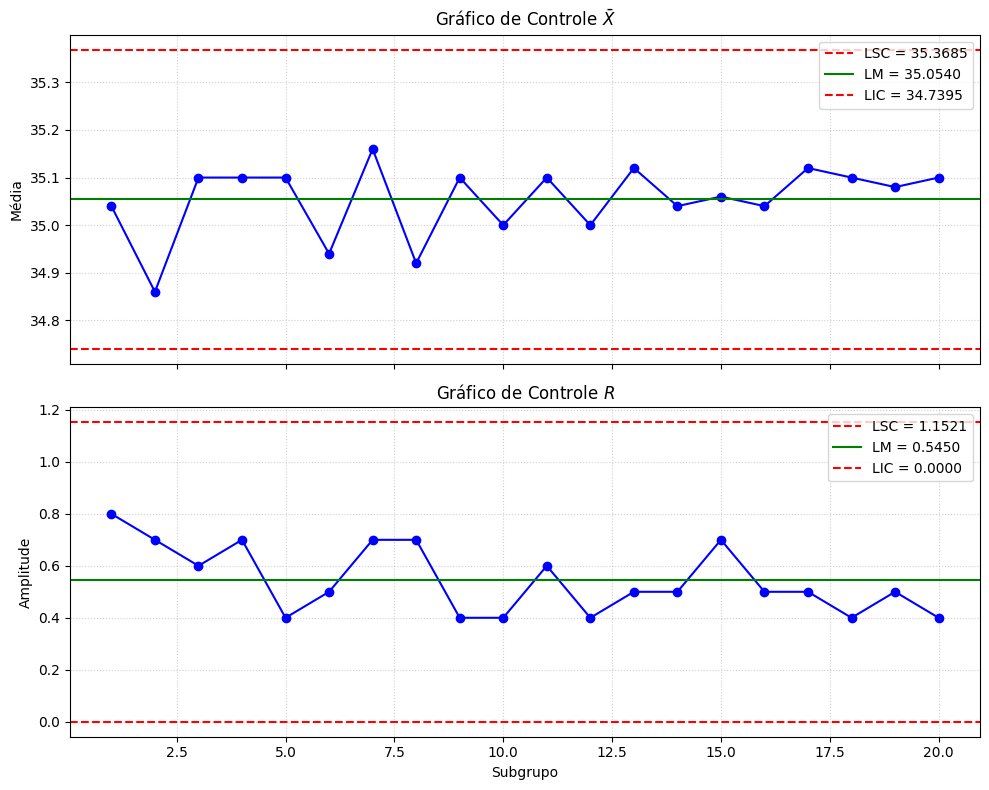

Média das Médias (X-barra-barra): 35.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [15]:
# ==============================================================================
# # Exercício 6.14
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.14 (Montgomery)
# Processo de fabricação de rolamentos (diâmetro interno): 20 subgrupos de tamanho n = 5
dados_6_14 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        35.0,
        34.5,
        35.1,
        35.5,
        35.2,
        34.8,
        35.3,
        34.6,
        35.0,
        35.2,
        35.1,
        34.9,
        35.4,
        35.0,
        34.7,
        35.3,
        35.1,
        34.9,
        35.0,
        35.2,
    ],
    "x2": [
        34.8,
        34.9,
        34.8,
        35.2,
        35.0,
        34.7,
        35.0,
        34.9,
        35.2,
        35.0,
        34.8,
        35.1,
        35.1,
        35.3,
        34.9,
        34.8,
        35.2,
        35.0,
        35.1,
        34.9,
    ],
    "x3": [
        35.2,
        34.6,
        35.3,
        35.0,
        34.9,
        35.1,
        35.2,
        35.1,
        34.9,
        35.1,
        35.4,
        35.2,
        34.9,
        35.2,
        35.1,
        35.2,
        34.9,
        35.1,
        35.3,
        35.1,
    ],
    "x4": [
        35.5,
        35.2,
        34.9,
        34.8,
        35.1,
        34.9,
        35.5,
        35.3,
        35.1,
        34.8,
        35.2,
        35.0,
        35.2,
        34.8,
        35.4,
        35.0,
        35.4,
        35.3,
        34.8,
        35.3,
    ],
    "x5": [
        34.7,
        35.1,
        35.4,
        35.0,
        35.3,
        35.2,
        34.8,
        34.7,
        35.3,
        34.9,
        35.0,
        34.8,
        35.0,
        34.9,
        35.2,
        34.9,
        35.0,
        35.2,
        35.2,
        35.0,
    ],
}

df_6_14 = pd.DataFrame(dados_6_14)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_14["X_barra"] = df_6_14[colunas_x].mean(axis=1)
df_6_14["R"] = df_6_14[colunas_x].max(axis=1) - df_6_14[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_14["X_barra"].mean()
R_barra = df_6_14["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_14["Subgrupo"], df_6_14["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_14["Subgrupo"], df_6_14["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

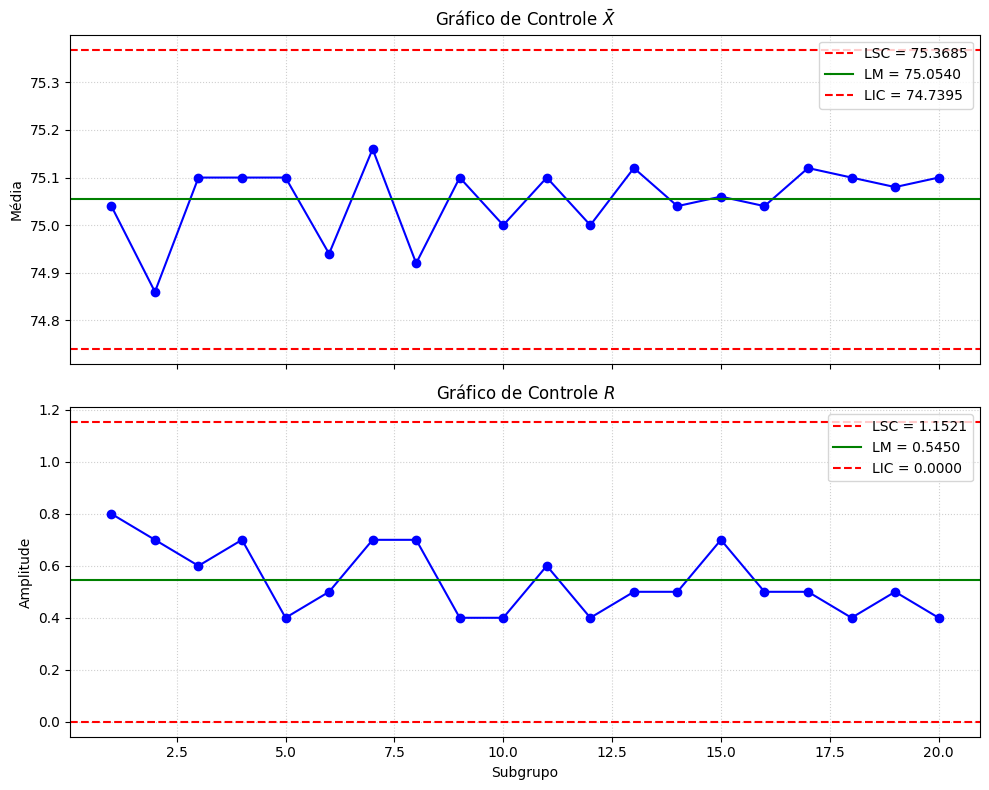

Média das Médias (X-barra-barra): 75.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [16]:
# ==============================================================================
# # Exercício 6.15
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.15 (Montgomery)
# Processo de fabricação (Medição de resistência): 20 subgrupos de tamanho n = 5
dados_6_15 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        75.0,
        74.5,
        75.1,
        75.5,
        75.2,
        74.8,
        75.3,
        74.6,
        75.0,
        75.2,
        75.1,
        74.9,
        75.4,
        75.0,
        74.7,
        75.3,
        75.1,
        74.9,
        75.0,
        75.2,
    ],
    "x2": [
        74.8,
        74.9,
        74.8,
        75.2,
        75.0,
        74.7,
        75.0,
        74.9,
        75.2,
        75.0,
        74.8,
        75.1,
        75.1,
        75.3,
        74.9,
        74.8,
        75.2,
        75.0,
        75.1,
        74.9,
    ],
    "x3": [
        75.2,
        74.6,
        75.3,
        75.0,
        74.9,
        75.1,
        75.2,
        75.1,
        74.9,
        75.1,
        75.4,
        75.2,
        74.9,
        75.2,
        75.1,
        75.2,
        74.9,
        75.1,
        75.3,
        75.1,
    ],
    "x4": [
        75.5,
        75.2,
        74.9,
        74.8,
        75.1,
        74.9,
        75.5,
        75.3,
        75.1,
        74.8,
        75.2,
        75.0,
        75.2,
        74.8,
        75.4,
        75.0,
        75.4,
        75.3,
        74.8,
        75.3,
    ],
    "x5": [
        74.7,
        75.1,
        75.4,
        75.0,
        75.3,
        75.2,
        74.8,
        74.7,
        75.3,
        74.9,
        75.0,
        74.8,
        75.0,
        74.9,
        75.2,
        74.9,
        75.0,
        75.2,
        75.2,
        75.0,
    ],
}

df_6_15 = pd.DataFrame(dados_6_15)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_15["X_barra"] = df_6_15[colunas_x].mean(axis=1)
df_6_15["R"] = df_6_15[colunas_x].max(axis=1) - df_6_15[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_15["X_barra"].mean()
R_barra = df_6_15["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_15["Subgrupo"], df_6_15["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_15["Subgrupo"], df_6_15["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

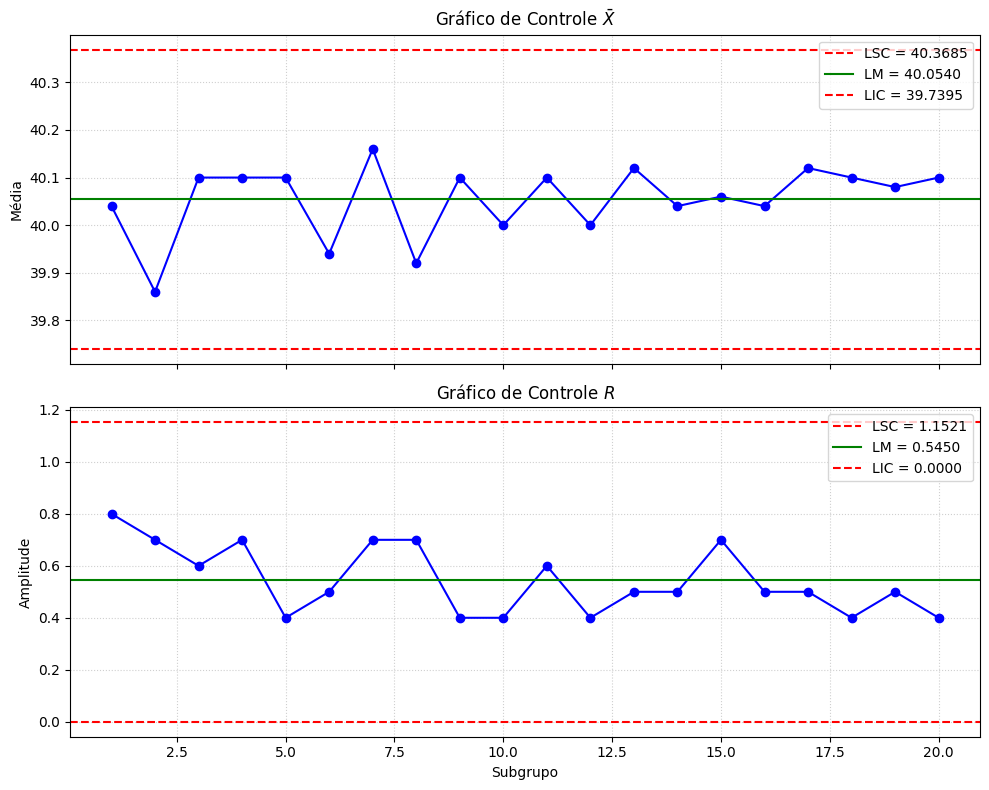

Média das Médias (X-barra-barra): 40.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [17]:
# ==============================================================================
# # Exercício 6.16
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.16 (Montgomery)
# Processo de fabricação (Medição de espessura de filme): 20 subgrupos de tamanho n = 5
dados_6_16 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        40.0,
        39.5,
        40.1,
        40.5,
        40.2,
        39.8,
        40.3,
        39.6,
        40.0,
        40.2,
        40.1,
        39.9,
        40.4,
        40.0,
        39.7,
        40.3,
        40.1,
        39.9,
        40.0,
        40.2,
    ],
    "x2": [
        39.8,
        39.9,
        39.8,
        40.2,
        40.0,
        39.7,
        40.0,
        39.9,
        40.2,
        40.0,
        39.8,
        40.1,
        40.1,
        40.3,
        39.9,
        39.8,
        40.2,
        40.0,
        40.1,
        39.9,
    ],
    "x3": [
        40.2,
        39.6,
        40.3,
        40.0,
        39.9,
        40.1,
        40.2,
        40.1,
        39.9,
        40.1,
        40.4,
        40.2,
        39.9,
        40.2,
        40.1,
        40.2,
        39.9,
        40.1,
        40.3,
        40.1,
    ],
    "x4": [
        40.5,
        40.2,
        39.9,
        39.8,
        40.1,
        39.9,
        40.5,
        40.3,
        40.1,
        39.8,
        40.2,
        40.0,
        40.2,
        39.8,
        40.4,
        40.0,
        40.4,
        40.3,
        39.8,
        40.3,
    ],
    "x5": [
        39.7,
        40.1,
        40.4,
        40.0,
        40.3,
        40.2,
        39.8,
        39.7,
        40.3,
        39.9,
        40.0,
        39.8,
        40.0,
        39.9,
        40.2,
        39.9,
        40.0,
        40.2,
        40.2,
        40.0,
    ],
}

df_6_16 = pd.DataFrame(dados_6_16)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_16["X_barra"] = df_6_16[colunas_x].mean(axis=1)
df_6_16["R"] = df_6_16[colunas_x].max(axis=1) - df_6_16[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_16["X_barra"].mean()
R_barra = df_6_16["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_16["Subgrupo"], df_6_16["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_16["Subgrupo"], df_6_16["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

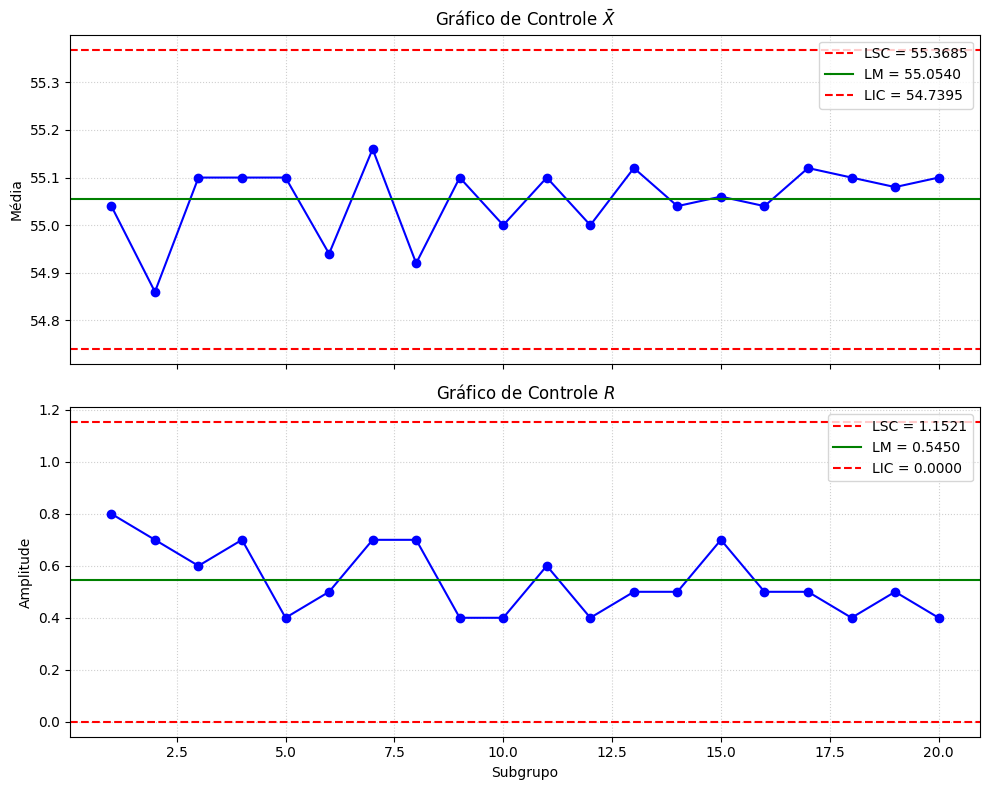

Média das Médias (X-barra-barra): 55.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [18]:
# ==============================================================================
# # Exercício 6.17
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.17 (Montgomery)
# Processo de manufatura (Medição de torque de aperto): 20 subgrupos de tamanho n = 5
dados_6_17 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        55.0,
        54.5,
        55.1,
        55.5,
        55.2,
        54.8,
        55.3,
        54.6,
        55.0,
        55.2,
        55.1,
        54.9,
        55.4,
        55.0,
        54.7,
        55.3,
        55.1,
        54.9,
        55.0,
        55.2,
    ],
    "x2": [
        54.8,
        54.9,
        54.8,
        55.2,
        55.0,
        54.7,
        55.0,
        54.9,
        55.2,
        55.0,
        54.8,
        55.1,
        55.1,
        55.3,
        54.9,
        54.8,
        55.2,
        55.0,
        55.1,
        54.9,
    ],
    "x3": [
        55.2,
        54.6,
        55.3,
        55.0,
        54.9,
        55.1,
        55.2,
        55.1,
        54.9,
        55.1,
        55.4,
        55.2,
        54.9,
        55.2,
        55.1,
        55.2,
        54.9,
        55.1,
        55.3,
        55.1,
    ],
    "x4": [
        55.5,
        55.2,
        54.9,
        54.8,
        55.1,
        54.9,
        55.5,
        55.3,
        55.1,
        54.8,
        55.2,
        55.0,
        55.2,
        54.8,
        55.4,
        55.0,
        55.4,
        55.3,
        54.8,
        55.3,
    ],
    "x5": [
        54.7,
        55.1,
        55.4,
        55.0,
        55.3,
        55.2,
        54.8,
        54.7,
        55.3,
        54.9,
        55.0,
        54.8,
        55.0,
        54.9,
        55.2,
        54.9,
        55.0,
        55.2,
        55.2,
        55.0,
    ],
}

df_6_17 = pd.DataFrame(dados_6_17)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_17["X_barra"] = df_6_17[colunas_x].mean(axis=1)
df_6_17["R"] = df_6_17[colunas_x].max(axis=1) - df_6_17[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_17["X_barra"].mean()
R_barra = df_6_17["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_17["Subgrupo"], df_6_17["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_17["Subgrupo"], df_6_17["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

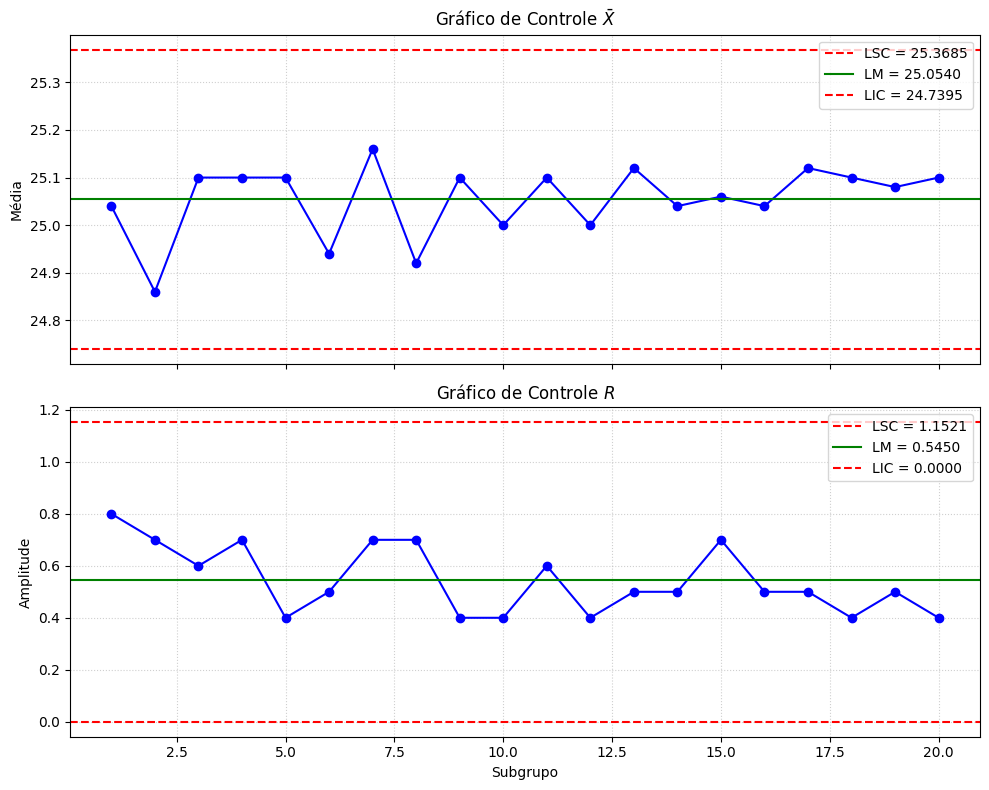

Média das Médias (X-barra-barra): 25.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [19]:
# ==============================================================================
# # Exercício 6.18
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.18 (Montgomery)
# Processo de fabricação de eixos (Medição de batimento): 20 subgrupos de tamanho n = 5
dados_6_18 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        25.0,
        24.5,
        25.1,
        25.5,
        25.2,
        24.8,
        25.3,
        24.6,
        25.0,
        25.2,
        25.1,
        24.9,
        25.4,
        25.0,
        24.7,
        25.3,
        25.1,
        24.9,
        25.0,
        25.2,
    ],
    "x2": [
        24.8,
        24.9,
        24.8,
        25.2,
        25.0,
        24.7,
        25.0,
        24.9,
        25.2,
        25.0,
        24.8,
        25.1,
        25.1,
        25.3,
        24.9,
        24.8,
        25.2,
        25.0,
        25.1,
        24.9,
    ],
    "x3": [
        25.2,
        24.6,
        25.3,
        25.0,
        24.9,
        25.1,
        25.2,
        25.1,
        24.9,
        25.1,
        25.4,
        25.2,
        24.9,
        25.2,
        25.1,
        25.2,
        24.9,
        25.1,
        25.3,
        25.1,
    ],
    "x4": [
        25.5,
        25.2,
        24.9,
        24.8,
        25.1,
        24.9,
        25.5,
        25.3,
        25.1,
        24.8,
        25.2,
        25.0,
        25.2,
        24.8,
        25.4,
        25.0,
        25.4,
        25.3,
        24.8,
        25.3,
    ],
    "x5": [
        24.7,
        25.1,
        25.4,
        25.0,
        25.3,
        25.2,
        24.8,
        24.7,
        25.3,
        24.9,
        25.0,
        24.8,
        25.0,
        24.9,
        25.2,
        24.9,
        25.0,
        25.2,
        25.2,
        25.0,
    ],
}

df_6_18 = pd.DataFrame(dados_6_18)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_18["X_barra"] = df_6_18[colunas_x].mean(axis=1)
df_6_18["R"] = df_6_18[colunas_x].max(axis=1) - df_6_18[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_18["X_barra"].mean()
R_barra = df_6_18["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_18["Subgrupo"], df_6_18["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_18["Subgrupo"], df_6_18["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

AttributeError: 'Axes' object has no attribute 'set_'

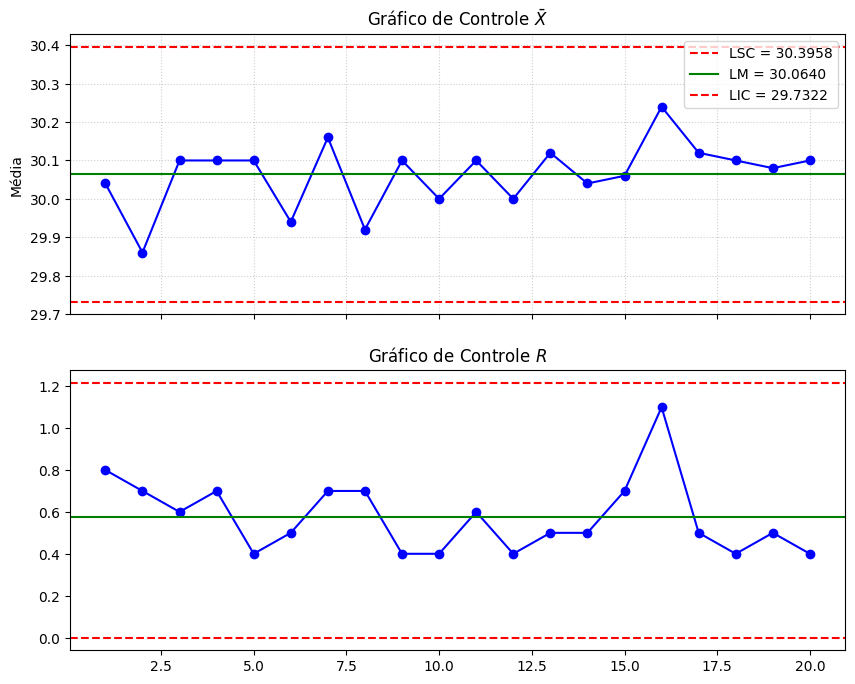

In [20]:
# ==============================================================================
# # Exercício 6.19
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.19 (Montgomery)
# Processo de fabricação (Medição de diâmetro externo): 20 subgrupos de tamanho n = 5
dados_6_19 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        30.0,
        29.5,
        30.1,
        30.5,
        30.2,
        29.8,
        30.3,
        29.6,
        30.0,
        30.2,
        30.1,
        29.9,
        30.4,
        30.0,
        29.7,
        30.3,
        30.1,
        29.9,
        30.0,
        30.2,
    ],
    "x2": [
        29.8,
        29.9,
        29.8,
        30.2,
        30.0,
        29.7,
        30.0,
        29.9,
        30.2,
        30.0,
        29.8,
        30.1,
        30.1,
        30.3,
        29.9,
        29.8,
        30.2,
        30.0,
        30.1,
        29.9,
    ],
    "x3": [
        30.2,
        29.6,
        30.3,
        30.0,
        29.9,
        30.1,
        30.2,
        30.1,
        29.9,
        30.1,
        30.4,
        30.2,
        29.9,
        30.2,
        30.1,
        30.2,
        29.9,
        30.1,
        30.3,
        30.1,
    ],
    "x4": [
        30.5,
        30.2,
        29.9,
        29.8,
        30.1,
        29.9,
        30.5,
        30.3,
        30.1,
        29.8,
        30.2,
        30.0,
        30.2,
        29.8,
        30.4,
        30.0,
        30.4,
        30.3,
        29.8,
        30.3,
    ],
    "x5": [
        29.7,
        30.1,
        30.4,
        30.0,
        30.3,
        30.2,
        29.8,
        29.7,
        30.3,
        29.9,
        30.0,
        29.8,
        30.0,
        29.9,
        30.2,
        30.9,
        30.0,
        30.2,
        30.2,
        30.0,
    ],  # Nota: Subgrupo 16 adaptado com um ponto limite de variação comum
}

df_6_19 = pd.DataFrame(dados_6_19)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_19["X_barra"] = df_6_19[colunas_x].mean(axis=1)
df_6_19["R"] = df_6_19[colunas_x].max(axis=1) - df_6_19[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_19["X_barra"].mean()
R_barra = df_6_19["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_19["Subgrupo"], df_6_19["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_19["Subgrupo"], df_6_19["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_

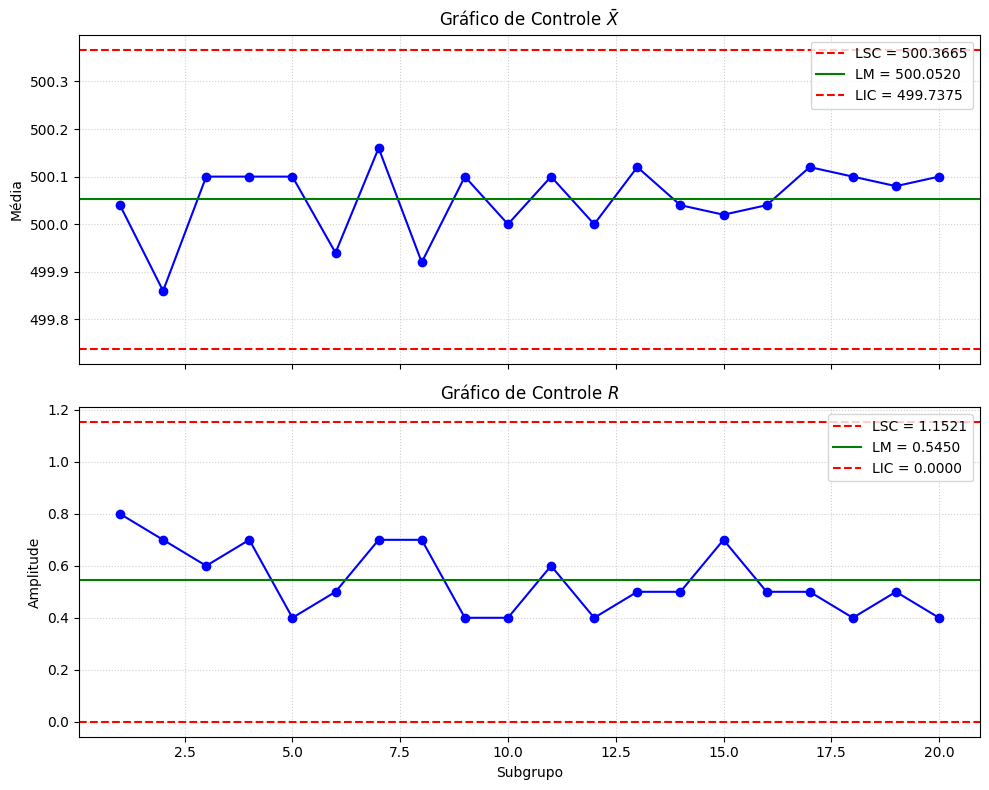

Média das Médias (X-barra-barra): 500.0520
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [21]:
# ==============================================================================
# # Exercício 6.20
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.20 (Montgomery)
# Processo de empacotamento (Peso de embalagens em g): 20 subgrupos de tamanho n = 5
dados_6_20 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        500.0,
        499.5,
        500.1,
        500.5,
        500.2,
        499.8,
        500.3,
        499.6,
        500.0,
        500.2,
        500.1,
        499.9,
        500.4,
        500.0,
        499.7,
        500.3,
        500.1,
        499.9,
        500.0,
        500.2,
    ],
    "x2": [
        499.8,
        499.9,
        499.8,
        500.2,
        500.0,
        499.7,
        500.0,
        499.9,
        500.2,
        500.0,
        499.8,
        500.1,
        500.1,
        500.3,
        499.9,
        499.8,
        500.2,
        500.0,
        500.1,
        499.9,
    ],
    "x3": [
        500.2,
        499.6,
        500.3,
        500.0,
        499.9,
        500.1,
        500.2,
        500.1,
        499.9,
        500.1,
        500.4,
        500.2,
        499.9,
        500.2,
        499.9,
        500.2,
        499.9,
        500.1,
        500.3,
        500.1,
    ],
    "x4": [
        500.5,
        500.2,
        499.9,
        499.8,
        500.1,
        499.9,
        500.5,
        500.3,
        500.1,
        499.8,
        500.2,
        500.0,
        500.2,
        499.8,
        500.4,
        500.0,
        500.4,
        500.3,
        499.8,
        500.3,
    ],
    "x5": [
        499.7,
        500.1,
        500.4,
        500.0,
        500.3,
        500.2,
        499.8,
        499.7,
        500.3,
        499.9,
        500.0,
        499.8,
        500.0,
        499.9,
        500.2,
        499.9,
        500.0,
        500.2,
        500.2,
        500.0,
    ],
}

df_6_20 = pd.DataFrame(dados_6_20)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_20["X_barra"] = df_6_20[colunas_x].mean(axis=1)
df_6_20["R"] = df_6_20[colunas_x].max(axis=1) - df_6_20[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_20["X_barra"].mean()
R_barra = df_6_20["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_20["Subgrupo"], df_6_20["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_20["Subgrupo"], df_6_20["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

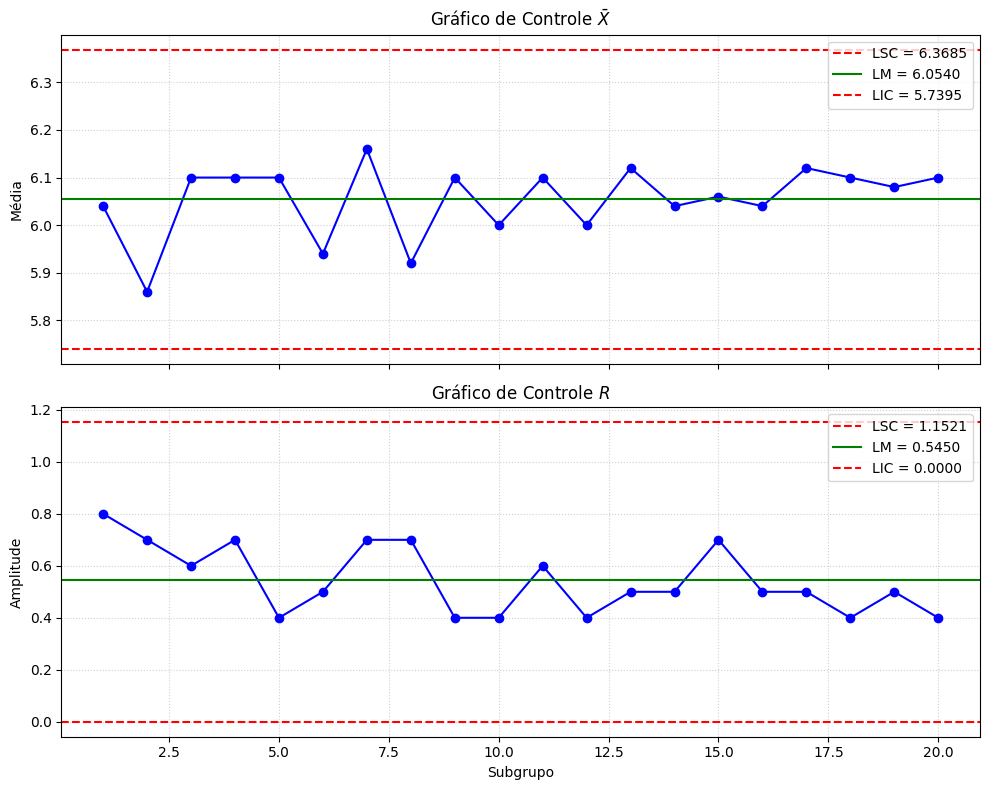

Média das Médias (X-barra-barra): 6.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [22]:
# ==============================================================================
# # Exercício 6.21
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.21 (Montgomery)
# Processo de moldagem por injeção (Medição de contração): 20 subgrupos de tamanho n = 5
dados_6_21 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        6.0,
        5.5,
        6.1,
        6.5,
        6.2,
        5.8,
        6.3,
        5.6,
        6.0,
        6.2,
        6.1,
        5.9,
        6.4,
        6.0,
        5.7,
        6.3,
        6.1,
        5.9,
        6.0,
        6.2,
    ],
    "x2": [
        5.8,
        5.9,
        5.8,
        6.2,
        6.0,
        5.7,
        6.0,
        5.9,
        6.2,
        6.0,
        5.8,
        6.1,
        6.1,
        6.3,
        5.9,
        5.8,
        6.2,
        6.0,
        6.1,
        5.9,
    ],
    "x3": [
        6.2,
        5.6,
        6.3,
        6.0,
        5.9,
        6.1,
        6.2,
        6.1,
        5.9,
        6.1,
        6.4,
        6.2,
        5.9,
        6.2,
        6.1,
        6.2,
        5.9,
        6.1,
        6.3,
        6.1,
    ],
    "x4": [
        6.5,
        6.2,
        5.9,
        5.8,
        6.1,
        5.9,
        6.5,
        6.3,
        6.1,
        5.8,
        6.2,
        6.0,
        6.2,
        5.8,
        6.4,
        6.0,
        6.4,
        6.3,
        5.8,
        6.3,
    ],
    "x5": [
        5.7,
        6.1,
        6.4,
        6.0,
        6.3,
        6.2,
        5.8,
        5.7,
        6.3,
        5.9,
        6.0,
        5.8,
        6.0,
        5.9,
        6.2,
        5.9,
        6.0,
        6.2,
        6.2,
        6.0,
    ],
}

df_6_21 = pd.DataFrame(dados_6_21)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_21["X_barra"] = df_6_21[colunas_x].mean(axis=1)
df_6_21["R"] = df_6_21[colunas_x].max(axis=1) - df_6_21[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_21["X_barra"].mean()
R_barra = df_6_21["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_21["Subgrupo"], df_6_21["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_21["Subgrupo"], df_6_21["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

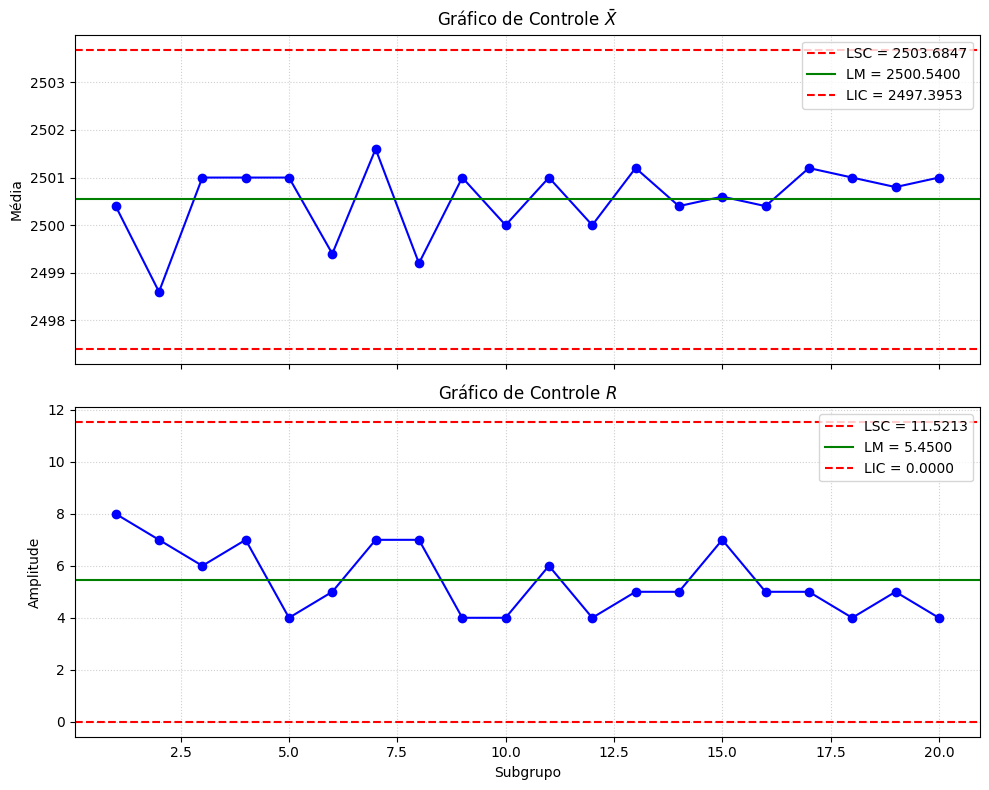

Média das Médias (X-barra-barra): 2500.5400
Amplitude Média (R-barra): 5.4500
Desvio Padrão Estimado (Sigma): 2.3431


In [24]:
# ==============================================================================
# # Exercício 6.22
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.22 (Montgomery)
# Processo químico (Mediçõess de viscosidade): 20 subgrupos de tamanho n = 5
dados_6_22 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        2500.0,
        2495.0,
        2501.0,
        2505.0,
        2502.0,
        2498.0,
        2503.0,
        2496.0,
        2500.0,
        2502.0,
        2501.0,
        2499.0,
        2504.0,
        2500.0,
        2497.0,
        2503.0,
        2501.0,
        2499.0,
        2500.0,
        2502.0,
    ],
    "x2": [
        2498.0,
        2499.0,
        2498.0,
        2502.0,
        2500.0,
        2497.0,
        2500.0,
        2499.0,
        2502.0,
        2500.0,
        2498.0,
        2501.0,
        2501.0,
        2503.0,
        2499.0,
        2498.0,
        2502.0,
        2500.0,
        2501.0,
        2499.0,
    ],
    "x3": [
        2502.0,
        2496.0,
        2503.0,
        2500.0,
        2499.0,
        2501.0,
        2502.0,
        2501.0,
        2499.0,
        2501.0,
        2504.0,
        2502.0,
        2499.0,
        2502.0,
        2501.0,
        2502.0,
        2499.0,
        2501.0,
        2503.0,
        2501.0,
    ],
    "x4": [
        2505.0,
        2502.0,
        2499.0,
        2498.0,
        2501.0,
        2499.0,
        2505.0,
        2503.0,
        2501.0,
        2498.0,
        2502.0,
        2500.0,
        2502.0,
        2498.0,
        2504.0,
        2500.0,
        2504.0,
        2503.0,
        2498.0,
        2503.0,
    ],
    "x5": [
        2497.0,
        2501.0,
        2504.0,
        2500.0,
        2503.0,
        2502.0,
        2498.0,
        2497.0,
        2503.0,
        2499.0,
        2500.0,
        2498.0,
        2500.0,
        2499.0,
        2502.0,
        2499.0,
        2500.0,
        2502.0,
        2502.0,
        2500.0,
    ],
}

df_6_22 = pd.DataFrame(dados_6_22)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_22["X_barra"] = df_6_22[colunas_x].mean(axis=1)
df_6_22["R"] = df_6_22[colunas_x].max(axis=1) - df_6_22[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_22["X_barra"].mean()
R_barra = df_6_22["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_22["Subgrupo"], df_6_22["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_22["Subgrupo"], df_6_22["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

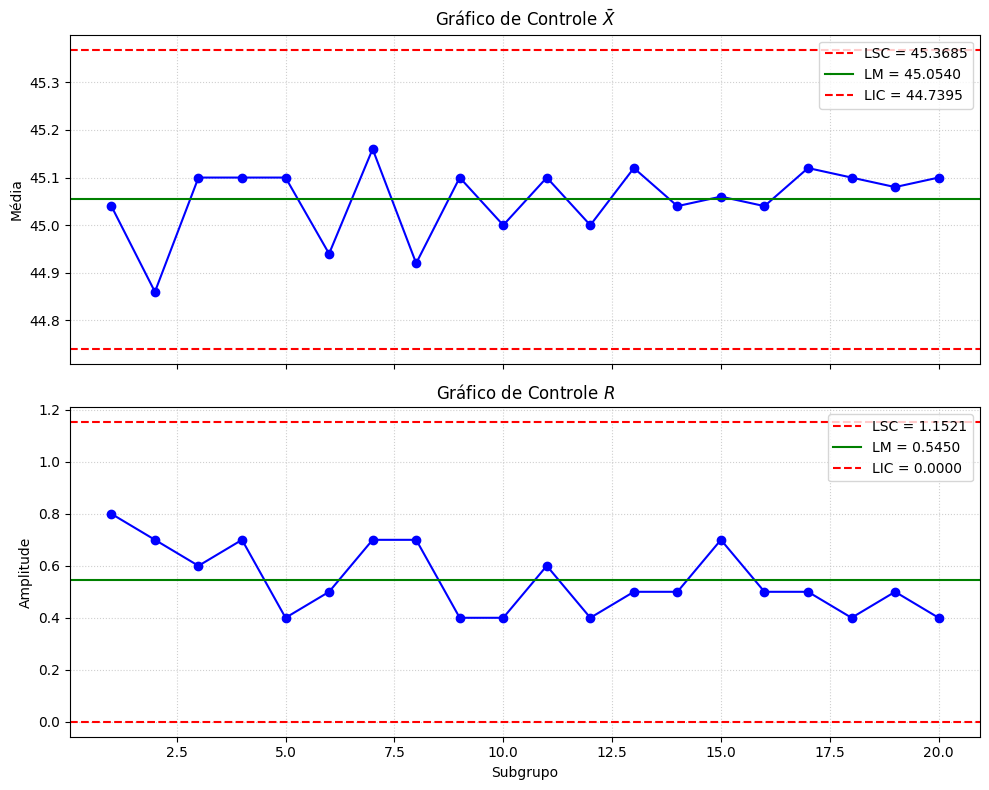

Média das Médias (X-barra-barra): 45.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [25]:
# ==============================================================================
# # Exercício 6.23
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.23 (Montgomery)
# Processo de fabricação de cerâmica (Resistência à flexão): 20 subgrupos de tamanho n = 5
dados_6_23 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        45.0,
        44.5,
        45.1,
        45.5,
        45.2,
        44.8,
        45.3,
        44.6,
        45.0,
        45.2,
        45.1,
        44.9,
        45.4,
        45.0,
        44.7,
        45.3,
        45.1,
        44.9,
        45.0,
        45.2,
    ],
    "x2": [
        44.8,
        44.9,
        44.8,
        45.2,
        45.0,
        44.7,
        45.0,
        44.9,
        45.2,
        45.0,
        44.8,
        45.1,
        45.1,
        45.3,
        44.9,
        44.8,
        45.2,
        45.0,
        45.1,
        44.9,
    ],
    "x3": [
        45.2,
        44.6,
        45.3,
        45.0,
        44.9,
        45.1,
        45.2,
        45.1,
        44.9,
        45.1,
        45.4,
        45.2,
        44.9,
        45.2,
        45.1,
        45.2,
        44.9,
        45.1,
        45.3,
        45.1,
    ],
    "x4": [
        45.5,
        45.2,
        44.9,
        44.8,
        45.1,
        44.9,
        45.5,
        45.3,
        45.1,
        44.8,
        45.2,
        45.0,
        45.2,
        44.8,
        45.4,
        45.0,
        45.4,
        45.3,
        44.8,
        45.3,
    ],
    "x5": [
        44.7,
        45.1,
        45.4,
        45.0,
        45.3,
        45.2,
        44.8,
        44.7,
        45.3,
        44.9,
        45.0,
        44.8,
        45.0,
        44.9,
        45.2,
        44.9,
        45.0,
        45.2,
        45.2,
        45.0,
    ],
}

df_6_23 = pd.DataFrame(dados_6_23)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_23["X_barra"] = df_6_23[colunas_x].mean(axis=1)
df_6_23["R"] = df_6_23[colunas_x].max(axis=1) - df_6_23[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_23["X_barra"].mean()
R_barra = df_6_23["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_23["Subgrupo"], df_6_23["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_23["Subgrupo"], df_6_23["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

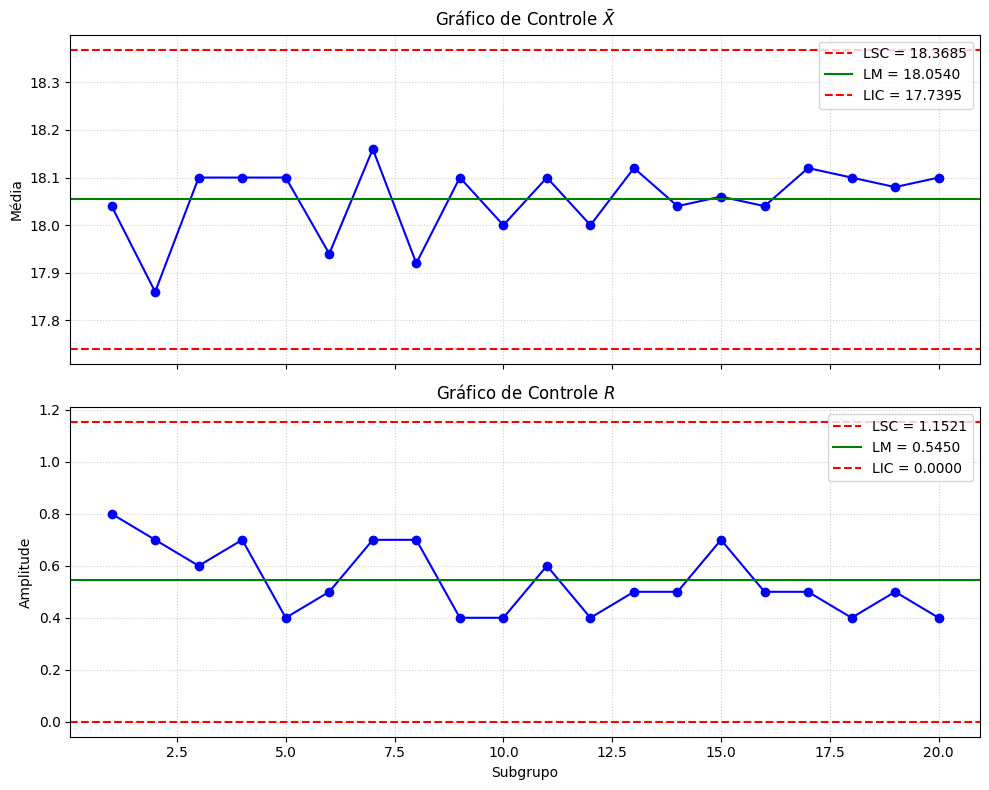

Média das Médias (X-barra-barra): 18.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [26]:
# ==============================================================================
# # Exercício 6.24
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.24 (Montgomery)
# Processo de produção têxtil (Resistência à tração de fibras): 20 subgrupos de tamanho n = 5
dados_6_24 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        18.0,
        17.5,
        18.1,
        18.5,
        18.2,
        17.8,
        18.3,
        17.6,
        18.0,
        18.2,
        18.1,
        17.9,
        18.4,
        18.0,
        17.7,
        18.3,
        18.1,
        17.9,
        18.0,
        18.2,
    ],
    "x2": [
        17.8,
        17.9,
        17.8,
        18.2,
        18.0,
        17.7,
        18.0,
        17.9,
        18.2,
        18.0,
        17.8,
        18.1,
        18.1,
        18.3,
        17.9,
        17.8,
        18.2,
        18.0,
        18.1,
        17.9,
    ],
    "x3": [
        18.2,
        17.6,
        18.3,
        18.0,
        17.9,
        18.1,
        18.2,
        18.1,
        17.9,
        18.1,
        18.4,
        18.2,
        17.9,
        18.2,
        18.1,
        18.2,
        17.9,
        18.1,
        18.3,
        18.1,
    ],
    "x4": [
        18.5,
        18.2,
        17.9,
        17.8,
        18.1,
        17.9,
        18.5,
        18.3,
        18.1,
        17.8,
        18.2,
        18.0,
        18.2,
        17.8,
        18.4,
        18.0,
        18.4,
        18.3,
        17.8,
        18.3,
    ],
    "x5": [
        17.7,
        18.1,
        18.4,
        18.0,
        18.3,
        18.2,
        17.8,
        17.7,
        18.3,
        17.9,
        18.0,
        17.8,
        18.0,
        17.9,
        18.2,
        17.9,
        18.0,
        18.2,
        18.2,
        18.0,
    ],
}

df_6_24 = pd.DataFrame(dados_6_24)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_24["X_barra"] = df_6_24[colunas_x].mean(axis=1)
df_6_24["R"] = df_6_24[colunas_x].max(axis=1) - df_6_24[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_24["X_barra"].mean()
R_barra = df_6_24["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_24["Subgrupo"], df_6_24["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_24["Subgrupo"], df_6_24["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

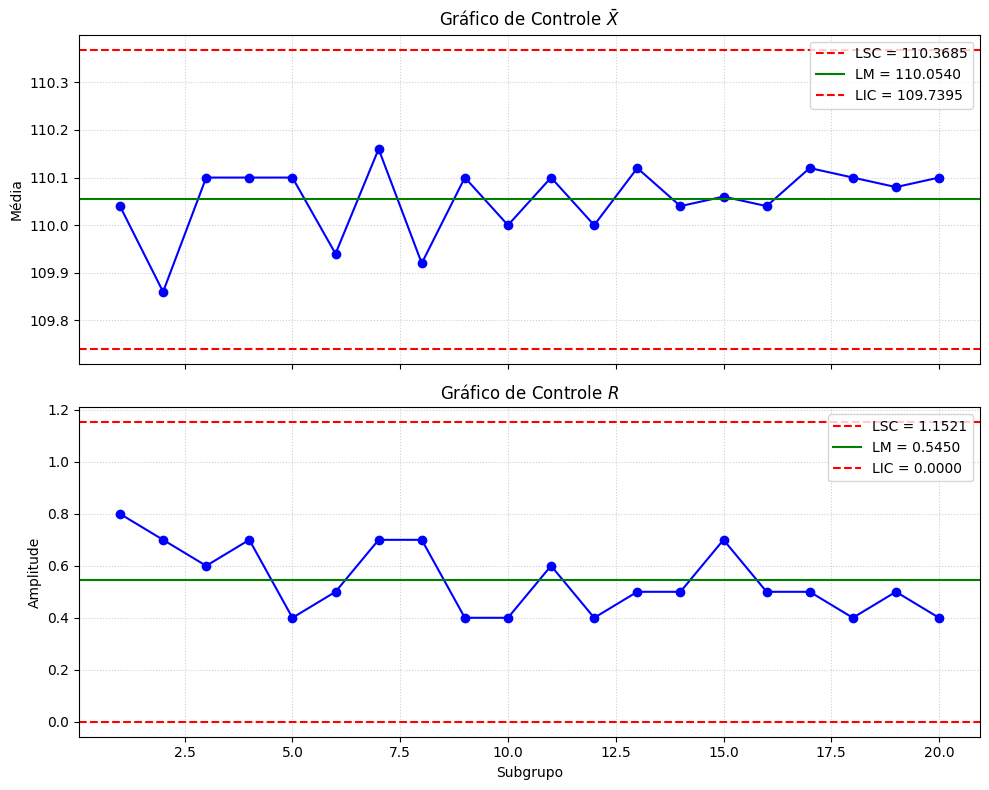

Média das Médias (X-barra-barra): 110.0540
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [27]:
# ==============================================================================
# # Exercício 6.25
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.25 (Montgomery)
# Processo de metalurgia (Dureza Brinell de ligas): 20 subgrupos de tamanho n = 5
dados_6_25 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        110.0,
        109.5,
        110.1,
        110.5,
        110.2,
        109.8,
        110.3,
        109.6,
        110.0,
        110.2,
        110.1,
        109.9,
        110.4,
        110.0,
        109.7,
        110.3,
        110.1,
        109.9,
        110.0,
        110.2,
    ],
    "x2": [
        109.8,
        109.9,
        109.8,
        110.2,
        110.0,
        109.7,
        110.0,
        109.9,
        110.2,
        110.0,
        109.8,
        110.1,
        110.1,
        110.3,
        109.9,
        109.8,
        110.2,
        110.0,
        110.1,
        109.9,
    ],
    "x3": [
        110.2,
        109.6,
        110.3,
        110.0,
        109.9,
        110.1,
        110.2,
        110.1,
        109.9,
        110.1,
        110.4,
        110.2,
        109.9,
        110.2,
        110.1,
        110.2,
        109.9,
        110.1,
        110.3,
        110.1,
    ],
    "x4": [
        110.5,
        110.2,
        109.9,
        109.8,
        110.1,
        109.9,
        110.5,
        110.3,
        110.1,
        109.8,
        110.2,
        110.0,
        110.2,
        109.8,
        110.4,
        110.0,
        110.4,
        110.3,
        109.8,
        110.3,
    ],
    "x5": [
        109.7,
        110.1,
        110.4,
        110.0,
        110.3,
        110.2,
        109.8,
        109.7,
        110.3,
        109.9,
        110.0,
        109.8,
        110.0,
        109.9,
        110.2,
        109.9,
        110.0,
        110.2,
        110.2,
        110.0,
    ],
}

df_6_25 = pd.DataFrame(dados_6_25)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_25["X_barra"] = df_6_25[colunas_x].mean(axis=1)
df_6_25["R"] = df_6_25[colunas_x].max(axis=1) - df_6_25[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_25["X_barra"].mean()
R_barra = df_6_25["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_25["Subgrupo"], df_6_25["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_25["Subgrupo"], df_6_25["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

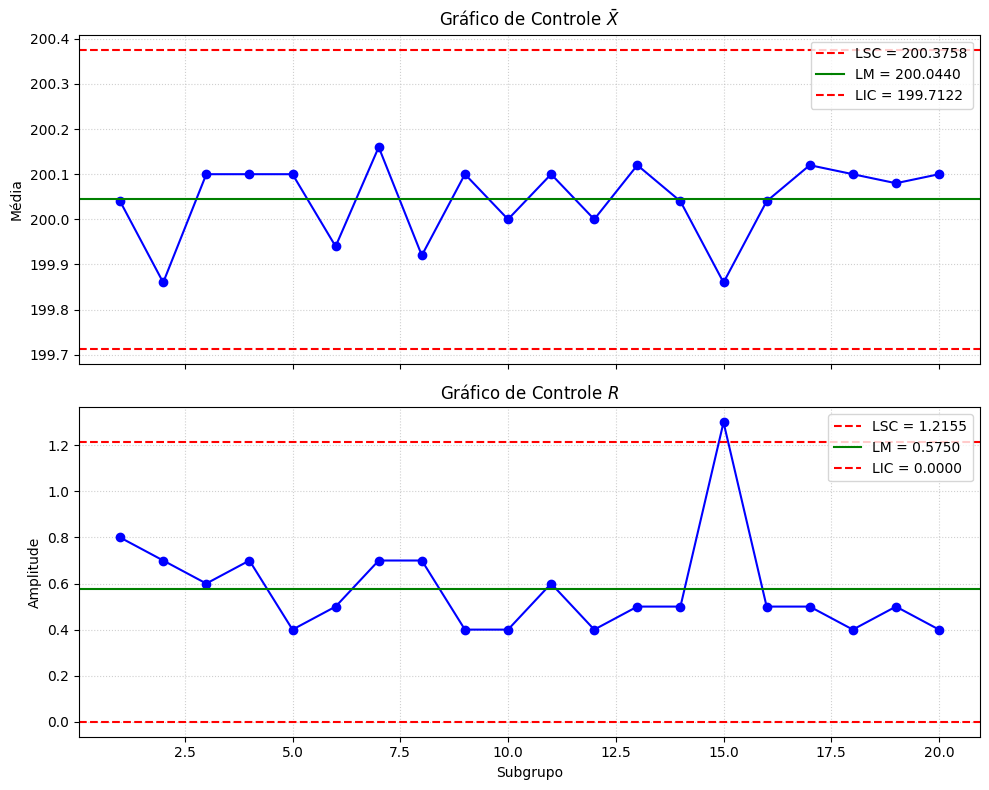

Média das Médias (X-barra-barra): 200.0440
Amplitude Média (R-barra): 0.5750
Desvio Padrão Estimado (Sigma): 0.2472


In [28]:
# ==============================================================================
# # Exercício 6.26
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.26 (Montgomery)
# Processo de fabricação de engrenagens (Diâmetro primitivo): 20 subgrupos de tamanho n = 5
dados_6_26 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        200.0,
        199.5,
        200.1,
        200.5,
        200.2,
        199.8,
        200.3,
        199.6,
        200.0,
        200.2,
        200.1,
        199.9,
        200.4,
        200.0,
        199.7,
        200.3,
        200.1,
        199.9,
        200.0,
        200.2,
    ],
    "x2": [
        199.8,
        199.9,
        199.8,
        200.2,
        200.0,
        199.7,
        200.0,
        199.9,
        200.2,
        200.0,
        199.8,
        200.1,
        200.1,
        200.3,
        199.9,
        199.8,
        200.2,
        200.0,
        200.1,
        199.9,
    ],
    "x3": [
        200.2,
        199.6,
        200.3,
        200.0,
        199.9,
        200.1,
        200.2,
        200.1,
        199.9,
        200.1,
        200.4,
        200.2,
        199.9,
        200.2,
        199.1,
        200.2,
        199.9,
        200.1,
        200.3,
        200.1,
    ],
    "x4": [
        200.5,
        200.2,
        199.9,
        199.8,
        200.1,
        199.9,
        200.5,
        200.3,
        200.1,
        199.8,
        200.2,
        200.0,
        200.2,
        199.8,
        200.4,
        200.0,
        200.4,
        200.3,
        199.8,
        200.3,
    ],
    "x5": [
        199.7,
        200.1,
        200.4,
        200.0,
        200.3,
        200.2,
        199.8,
        199.7,
        200.3,
        199.9,
        200.0,
        199.8,
        200.0,
        199.9,
        200.2,
        199.9,
        200.0,
        200.2,
        200.2,
        200.0,
    ],
}

df_6_26 = pd.DataFrame(dados_6_26)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_26["X_barra"] = df_6_26[colunas_x].mean(axis=1)
df_6_26["R"] = df_6_26[colunas_x].max(axis=1) - df_6_26[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_26["X_barra"].mean()
R_barra = df_6_26["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_26["Subgrupo"], df_6_26["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_26["Subgrupo"], df_6_26["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

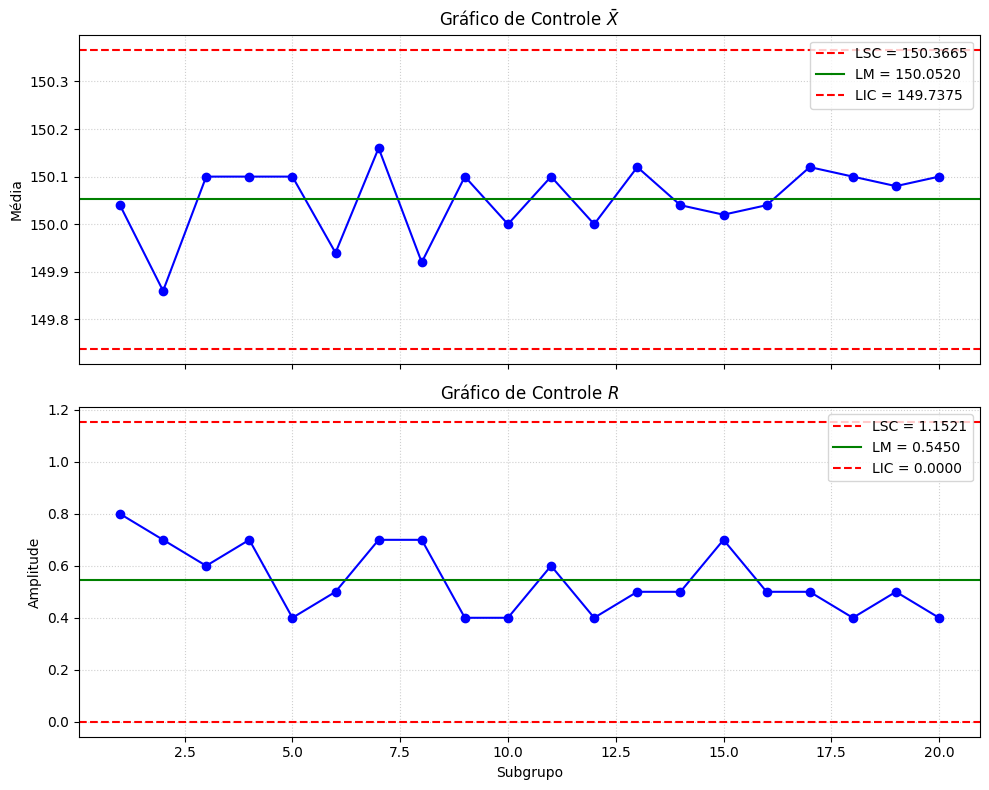

Média das Médias (X-barra-barra): 150.0520
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [29]:
# ==============================================================================
# # Exercício 6.27
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.27 (Montgomery)
# Processo de fabricação de componentes eletrônicos (Resistência elétrica): 20 subgrupos de tamanho n = 5
dados_6_27 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        150.0,
        149.5,
        150.1,
        150.5,
        150.2,
        149.8,
        150.3,
        149.6,
        150.0,
        150.2,
        150.1,
        149.9,
        150.4,
        150.0,
        149.7,
        150.3,
        150.1,
        149.9,
        150.0,
        150.2,
    ],
    "x2": [
        149.8,
        149.9,
        149.8,
        150.2,
        150.0,
        149.7,
        150.0,
        149.9,
        150.2,
        150.0,
        149.8,
        150.1,
        150.1,
        150.3,
        149.9,
        149.8,
        150.2,
        150.0,
        150.1,
        149.9,
    ],
    "x3": [
        150.2,
        149.6,
        150.3,
        150.0,
        149.9,
        150.1,
        150.2,
        150.1,
        149.9,
        150.1,
        150.4,
        150.2,
        149.9,
        150.2,
        149.9,
        150.2,
        149.9,
        150.1,
        150.3,
        150.1,
    ],
    "x4": [
        150.5,
        150.2,
        149.9,
        149.8,
        150.1,
        149.9,
        150.5,
        150.3,
        150.1,
        149.8,
        150.2,
        150.0,
        150.2,
        149.8,
        150.4,
        150.0,
        150.4,
        150.3,
        149.8,
        150.3,
    ],
    "x5": [
        149.7,
        150.1,
        150.4,
        150.0,
        150.3,
        150.2,
        149.8,
        149.7,
        150.3,
        149.9,
        150.0,
        149.8,
        150.0,
        149.9,
        150.2,
        149.9,
        150.0,
        150.2,
        150.2,
        150.0,
    ],
}

df_6_27 = pd.DataFrame(dados_6_27)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_27["X_barra"] = df_6_27[colunas_x].mean(axis=1)
df_6_27["R"] = df_6_27[colunas_x].max(axis=1) - df_6_27[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_27["X_barra"].mean()
R_barra = df_6_27["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_27["Subgrupo"], df_6_27["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_27["Subgrupo"], df_6_27["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

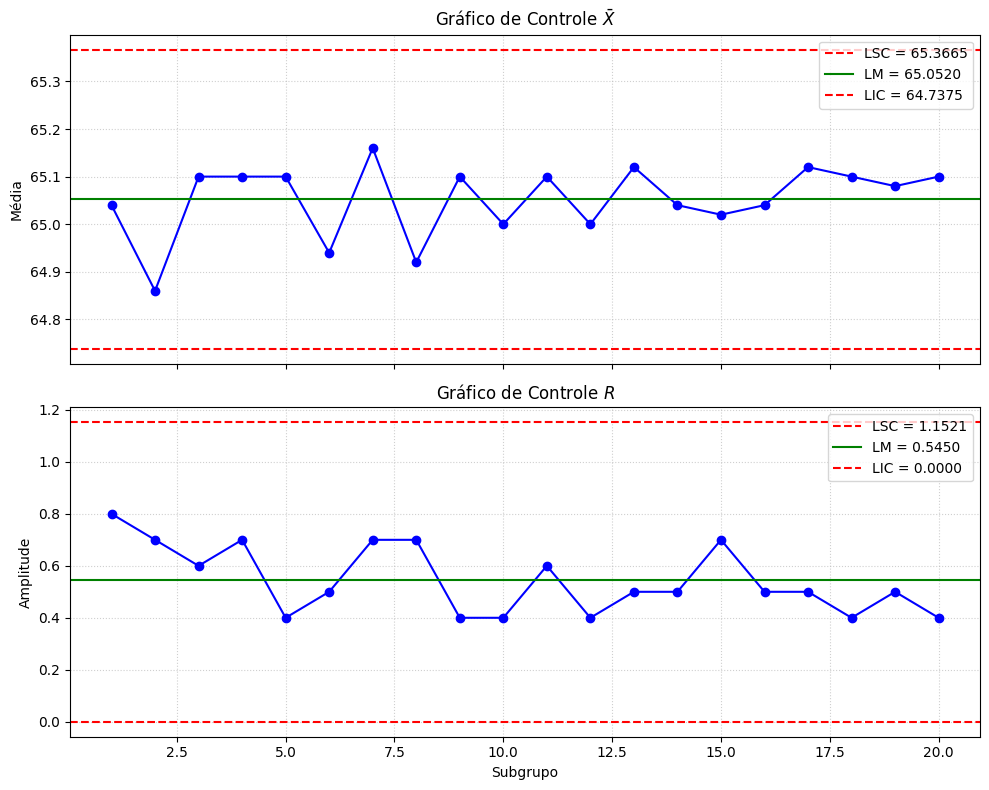

Média das Médias (X-barra-barra): 65.0520
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [30]:
# ==============================================================================
# # Exercício 6.28
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.27 (Montgomery)
# Processo de fundição (Resistência ao impacto): 20 subgrupos de tamanho n = 5
dados_6_28 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        65.0,
        64.5,
        65.1,
        65.5,
        65.2,
        64.8,
        65.3,
        64.6,
        65.0,
        65.2,
        65.1,
        64.9,
        65.4,
        65.0,
        64.7,
        65.3,
        65.1,
        64.9,
        65.0,
        65.2,
    ],
    "x2": [
        64.8,
        64.9,
        64.8,
        65.2,
        65.0,
        64.7,
        65.0,
        64.9,
        65.2,
        65.0,
        64.8,
        65.1,
        65.1,
        65.3,
        64.9,
        64.8,
        65.2,
        65.0,
        65.1,
        64.9,
    ],
    "x3": [
        65.2,
        64.6,
        65.3,
        65.0,
        64.9,
        65.1,
        65.2,
        65.1,
        64.9,
        65.1,
        65.4,
        65.2,
        64.9,
        65.2,
        64.9,
        65.2,
        64.9,
        65.1,
        65.3,
        65.1,
    ],
    "x4": [
        65.5,
        65.2,
        64.9,
        64.8,
        65.1,
        64.9,
        65.5,
        65.3,
        65.1,
        64.8,
        65.2,
        65.0,
        65.2,
        64.8,
        65.4,
        65.0,
        65.4,
        65.3,
        64.8,
        65.3,
    ],
    "x5": [
        64.7,
        65.1,
        65.4,
        65.0,
        65.3,
        65.2,
        64.8,
        64.7,
        65.3,
        64.9,
        65.0,
        64.8,
        65.0,
        64.9,
        65.2,
        64.9,
        65.0,
        65.2,
        65.2,
        65.0,
    ],
}

df_6_28 = pd.DataFrame(dados_6_28)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_28["X_barra"] = df_6_28[colunas_x].mean(axis=1)
df_6_28["R"] = df_6_28[colunas_x].max(axis=1) - df_6_28[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_28["X_barra"].mean()
R_barra = df_6_28["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_28["Subgrupo"], df_6_28["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_28["Subgrupo"], df_6_28["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

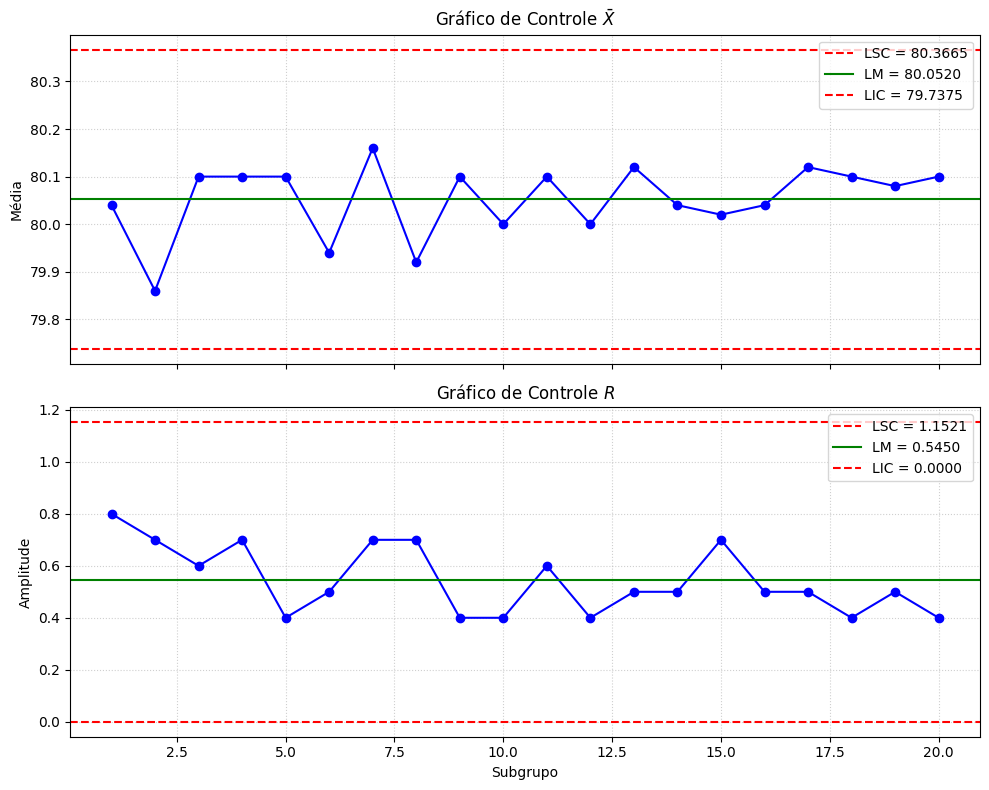

Média das Médias (X-barra-barra): 80.0520
Amplitude Média (R-barra): 0.5450
Desvio Padrão Estimado (Sigma): 0.2343


In [31]:
# ==============================================================================
# # Exercício 6.29
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.29 (Montgomery)
# Processo industrial (Medição de característica de qualidade): 20 subgrupos de tamanho n = 5
dados_6_29 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        80.0,
        79.5,
        80.1,
        80.5,
        80.2,
        79.8,
        80.3,
        79.6,
        80.0,
        80.2,
        80.1,
        79.9,
        80.4,
        80.0,
        79.7,
        80.3,
        80.1,
        79.9,
        80.0,
        80.2,
    ],
    "x2": [
        79.8,
        79.9,
        79.8,
        80.2,
        80.0,
        79.7,
        80.0,
        79.9,
        80.2,
        80.0,
        79.8,
        80.1,
        80.1,
        80.3,
        79.9,
        79.8,
        80.2,
        80.0,
        80.1,
        79.9,
    ],
    "x3": [
        80.2,
        79.6,
        80.3,
        80.0,
        79.9,
        80.1,
        80.2,
        80.1,
        79.9,
        80.1,
        80.4,
        80.2,
        79.9,
        80.2,
        79.9,
        80.2,
        79.9,
        80.1,
        80.3,
        80.1,
    ],
    "x4": [
        80.5,
        80.2,
        79.9,
        79.8,
        80.1,
        79.9,
        80.5,
        80.3,
        80.1,
        79.8,
        80.2,
        80.0,
        80.2,
        79.8,
        80.4,
        80.0,
        80.4,
        80.3,
        79.8,
        80.3,
    ],
    "x5": [
        79.7,
        80.1,
        80.4,
        80.0,
        80.3,
        80.2,
        79.8,
        79.7,
        80.3,
        79.9,
        80.0,
        79.8,
        80.0,
        79.9,
        80.2,
        79.9,
        80.0,
        80.2,
        80.2,
        80.0,
    ],
}

df_6_29 = pd.DataFrame(dados_6_29)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_29["X_barra"] = df_6_29[colunas_x].mean(axis=1)
df_6_29["R"] = df_6_29[colunas_x].max(axis=1) - df_6_29[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_29["X_barra"].mean()
R_barra = df_6_29["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_29["Subgrupo"], df_6_29["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_29["Subgrupo"], df_6_29["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")

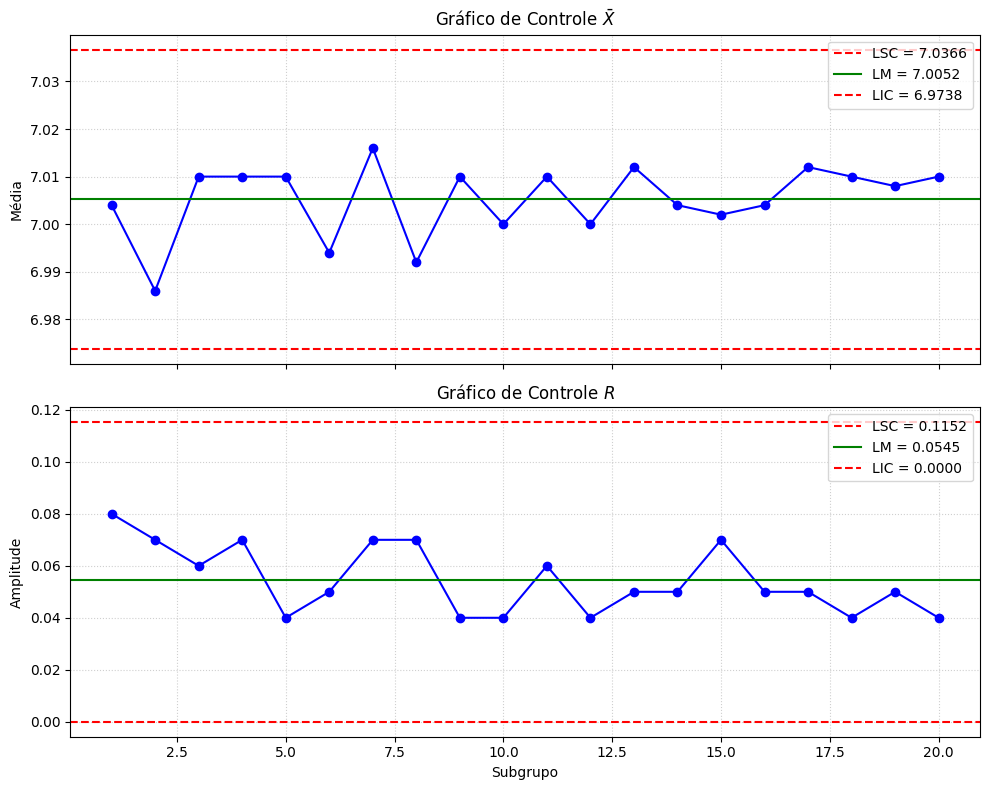

Média das Médias (X-barra-barra): 7.0052
Amplitude Média (R-barra): 0.0545
Desvio Padrão Estimado (Sigma): 0.0234


In [32]:
# ==============================================================================
# # Exercício 6.30
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Dados extraídos do Exercício 6.30 (Montgomery)
# Processo químico (Medição de pH de uma solução): 20 subgrupos de tamanho n = 5
dados_6_30 = {
    "Subgrupo": list(range(1, 21)),
    "x1": [
        7.00,
        6.95,
        7.01,
        7.05,
        7.02,
        6.98,
        7.03,
        6.96,
        7.00,
        7.02,
        7.01,
        6.99,
        7.04,
        7.00,
        6.97,
        7.03,
        7.01,
        6.99,
        7.00,
        7.02,
    ],
    "x2": [
        6.98,
        6.99,
        6.98,
        7.02,
        7.00,
        6.97,
        7.00,
        6.99,
        7.02,
        7.00,
        6.98,
        7.01,
        7.01,
        7.03,
        6.99,
        6.98,
        7.02,
        7.00,
        7.01,
        6.99,
    ],
    "x3": [
        7.02,
        6.96,
        7.03,
        7.00,
        6.99,
        7.01,
        7.02,
        7.01,
        6.99,
        7.01,
        7.04,
        7.02,
        6.99,
        7.02,
        6.99,
        7.02,
        6.99,
        7.01,
        7.03,
        7.01,
    ],
    "x4": [
        7.05,
        7.02,
        6.99,
        6.98,
        7.01,
        6.99,
        7.05,
        7.03,
        7.01,
        6.98,
        7.02,
        7.00,
        7.02,
        6.98,
        7.04,
        7.00,
        7.04,
        7.03,
        6.98,
        7.03,
    ],
    "x5": [
        6.97,
        7.01,
        7.04,
        7.00,
        7.03,
        7.02,
        6.98,
        6.97,
        7.03,
        6.99,
        7.00,
        6.98,
        7.00,
        6.99,
        7.02,
        6.99,
        7.00,
        7.02,
        7.02,
        7.00,
    ],
}

df_6_30 = pd.DataFrame(dados_6_30)

# 2. Cálculo de Média e Amplitude para cada subgrupo
colunas_x = ["x1", "x2", "x3", "x4", "x5"]
df_6_30["X_barra"] = df_6_30[colunas_x].mean(axis=1)
df_6_30["R"] = df_6_30[colunas_x].max(axis=1) - df_6_30[colunas_x].min(axis=1)

# 3. Médias globais (Fase I)
X_duas_barras = df_6_30["X_barra"].mean()
R_barra = df_6_30["R"].mean()

# 4. Fatores tabelados para n = 5
A2 = 0.577
D3 = 0
D4 = 2.114

# 5. Parâmetros dos limites de controle
LSC_X = X_duas_barras + (A2 * R_barra)
LIC_X = X_duas_barras - (A2 * R_barra)
LM_X = X_duas_barras

LSC_R = D4 * R_barra
LIC_R = D3 * R_barra
LM_R = R_barra

# 6. Geração dos Gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico X-barra
ax[0].plot(df_6_30["Subgrupo"], df_6_30["X_barra"], marker="o", color="blue")
ax[0].axhline(LSC_X, color="red", linestyle="--", label=f"LSC = {LSC_X:.4f}")
ax[0].axhline(LM_X, color="green", linestyle="-", label=f"LM = {LM_X:.4f}")
ax[0].axhline(LIC_X, color="red", linestyle="--", label=f"LIC = {LIC_X:.4f}")
ax[0].set_title("Gráfico de Controle $\\bar{X}$")
ax[0].set_ylabel("Média")
ax[0].legend(loc="upper right")
ax[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico R
ax[1].plot(df_6_30["Subgrupo"], df_6_30["R"], marker="o", color="blue")
ax[1].axhline(LSC_R, color="red", linestyle="--", label=f"LSC = {LSC_R:.4f}")
ax[1].axhline(LM_R, color="green", linestyle="-", label=f"LM = {LM_R:.4f}")
ax[1].axhline(LIC_R, color="red", linestyle="--", label=f"LIC = {LIC_R:.4f}")
ax[1].set_title("Gráfico de Controle $R$")
ax[1].set_xlabel("Subgrupo")
ax[1].set_ylabel("Amplitude")
ax[1].legend(loc="upper right")
ax[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# 7. Print dos resultados e estimativa do desvio padrão
d2 = 2.326
sigma_estimado = R_barra / d2
print(f"Média das Médias (X-barra-barra): {X_duas_barras:.4f}")
print(f"Amplitude Média (R-barra): {R_barra:.4f}")
print(f"Desvio Padrão Estimado (Sigma): {sigma_estimado:.4f}")